<a href="https://colab.research.google.com/github/shahnawazsyed/PaySimFraudDetection/blob/main/550_final_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Imports and set-up**

In [ ]:
!pip install xgboost --upgrade --no-cache-dir

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.9/253.9 MB 146.3 MB/s eta 0:00:00
  Attempting uninstall: xgboost
    Found existing installation: xgboost 2.1.4
    Uninstalling xgboost-2.1.4:
      Successfully uninstalled xgboost-2.1.4


In [ ]:
!pip install imbalanced-learn

In [ ]:
import pandas as pd
import numpy as np
import kagglehub
from kagglehub import KaggleDatasetAdapter
from sklearn.utils.class_weight import compute_class_weight
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_score, recall_score, make_scorer, f1_score, roc_auc_score, average_precision_score, precision_recall_curve, roc_curve, auc, classification_report, confusion_matrix, accuracy_score
from sklearn.ensemble import AdaBoostClassifier, RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.base import clone
import xgboost as xgb
from xgboost import XGBClassifier
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from IPython.display import display
from scipy import stats
from imblearn.over_sampling import SMOTE
from tqdm import tqdm
import warnings
import gc

In [ ]:
def myrmse(y,yhat): #not super useful since this is pretty imbalanced
   """ print out rmse with 3 digits"""
   #rmse = math.sqrt(mean_squared_error(y,yhat))
   rmse = np.sqrt(np.sum((y-yhat)**2)/len(y))
   return(np.round(rmse,3))

# **Data**

In [ ]:
file_path = "PS_20174392719_1491204439457_log.csv"

df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "ealaxi/paysim1",
  file_path,
  # Provide any additional arguments like
  # sql_query or pandas_kwargs. See the
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

<ipython-input-7-faf9323d4219>:3: DeprecationWarning: load_dataset is deprecated and will be removed in a future version.
  df = kagglehub.load_dataset(


In [ ]:
newColumnNames = ['step', 'type', 'amount', 'origCust', 'origOldBalance', 'origNewBalance', 'destCust', 'destOldBalance', 'destNewBalance', 'isFraud', 'isFlaggedFraud']
df.columns = newColumnNames #making the column names a little more intuitive

Step: Maps a unit of time in the real world. In this case 1 step is 1 hour of time.

Type: type of transaction (CASH-IN, CASH-OUT, DEBIT, PAYMENT and TRANSFER).

Amount: Amount of the transaction in local currency

origCust: Customer who started the transaction (ID)

origOldBalance: Original balance for the customer who started the transaction.

origNewBalance: New balance for the customer who started the transaction.

destCust: Customer who was on the receiving end of the transaction.

destOldBalance: Original balance for the customer on the receiving end of the transaction.

destNewBalance: New balance for the customer on the receiving end of the transaction.

isFraud: If the transaction was actually fraud.

isFlaggedFraud: Flags illegal attempts to transfer more than 200,000 in a single transaction. This is redundant with other fields so it will not be included in our final dataset.




In [ ]:
print(df.head())

   step      type    amount     origCust  origOldBalance  origNewBalance  \
0     1   PAYMENT   9839.64  C1231006815        170136.0       160296.36   
1     1   PAYMENT   1864.28  C1666544295         21249.0        19384.72   
2     1  TRANSFER    181.00  C1305486145           181.0            0.00   
3     1  CASH_OUT    181.00   C840083671           181.0            0.00   
4     1   PAYMENT  11668.14  C2048537720         41554.0        29885.86   

      destCust  destOldBalance  destNewBalance  isFraud  isFlaggedFraud  
0  M1979787155             0.0             0.0        0               0  
1  M2044282225             0.0             0.0        0               0  
2   C553264065             0.0             0.0        1               0  
3    C38997010         21182.0             0.0        1               0  
4  M1230701703             0.0             0.0        0               0  


In [ ]:
df.describe()

,step,amount,origOldBalance,origNewBalance,destOldBalance,destNewBalance,isFraud,isFlaggedFraud
count,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06
mean,2.433972e+02,1.798619e+05,8.338831e+05,8.551137e+05,1.100702e+06,1.224996e+06,1.290820e-03,2.514687e-06
std,1.423320e+02,6.038582e+05,2.888243e+06,2.924049e+06,3.399180e+06,3.674129e+06,3.590480e-02,1.585775e-03
min,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.560000e+02,1.338957e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2.390000e+02,7.487194e+04,1.420800e+04,0.000000e+00,1.327057e+05,2.146614e+05,0.000000e+00,0.000000e+00
75%,3.350000e+02,2.087215e+05,1.073152e+05,1.442584e+05,9.430367e+05,1.111909e+06,0.000000e+00,0.000000e+00
max,7.430000e+02,9.244552e+07,5.958504e+07,4.958504e+07,3.560159e+08,3.561793e+08,1.000000e+00,1.000000e+00


There is likely an imbalance in the dataset. Let's investigate by checking the skewness. We'll also ensure there are no missing values.

In [ ]:
numeric_vars = ['amount', 'origOldBalance', 'origNewBalance',
                'destOldBalance', 'destNewBalance',
                'isFraud']

print("\nSkewness of numeric columns:")
print(df[numeric_vars].skew())

print("\nMissing values in numeric columns:")
print(df[numeric_vars].isna().sum())

print("\nZero values in oldbalanceOrg:", (df['origOldBalance'] == 0).sum())
print("Zero values in newbalanceOrig:", (df['origNewBalance'] == 0).sum())



Skewness of numeric columns:
amount            30.993949
origOldBalance     5.249136
origNewBalance     5.176884
destOldBalance    19.921758
destNewBalance    19.352302
isFraud           27.779538
dtype: float64

Missing values in numeric columns:
amount            0
origOldBalance    0
origNewBalance    0
destOldBalance    0
destNewBalance    0
isFraud           0
dtype: int64

Zero values in oldbalanceOrg: 2102449
Zero values in newbalanceOrig: 3609566


Zero values for the balance is expected. But good to know that there are no nulls otherwise. As expected, though, our variables are quite skewed.

Since it is binary, isFraud being skewed isn't anything to worry about. On the other hand, we should probably handle the other numeric variables. Let's do a log transformation and see how that goes:

In [ ]:
def treat_skewness(df, skewed_vars):
    for col in skewed_vars:
        df[f'log_{col}'] = np.log1p(df[col])

    return df

skewed_vars = ['amount', 'origOldBalance', 'origNewBalance', 'destOldBalance', 'destNewBalance']

df = treat_skewness(df, skewed_vars)

#skewness before and after transformation
print("Skewness before transformation:")
print(df[skewed_vars].skew())

print("\nSkewness after transformation:")
print(df[[f'log_{col}' for col in skewed_vars]].skew())


Skewness before transformation:
amount            30.993949
origOldBalance     5.249136
origNewBalance     5.176884
destOldBalance    19.921758
destNewBalance    19.352302
dtype: float64

Skewness after transformation:
log_amount           -0.555018
log_origOldBalance   -0.259723
log_origNewBalance    0.440148
log_destOldBalance   -0.213261
log_destNewBalance   -0.386937
dtype: float64


Looks much better! Our skewness is pretty much between -0.5 and 0.5 which is approximately symmetrical.

The only exception is amount, which barely falls out at -0.555. This is fine and expected, as very large account balances will add some imbalance, but the log transformation does mitigate that a bit (it was almost 31 before!)

Next, we'll look at the class distribution for the non-numeric variables. Since some fields have a lot of unique values, we'll just look at the top 5 values.

In [ ]:
non_numeric_vars = df.select_dtypes(exclude='number').columns.tolist()

for col in non_numeric_vars:
    print(f"Value counts for '{col}':")
    print(df[col].value_counts().head())
    print("-" * 30)

for col in ['isFraud', 'isFlaggedFraud']:
    print(f"Value counts for '{col}':")
    print(df[col].value_counts())
    print("-" * 30)

Value counts for 'type':
type
CASH_OUT    2237500
PAYMENT     2151495
CASH_IN     1399284
TRANSFER     532909
DEBIT         41432
Name: count, dtype: int64
------------------------------
Value counts for 'origCust':
origCust
C1530544995    3
C545315117     3
C724452879     3
C1784010646    3
C1677795071    3
Name: count, dtype: int64
------------------------------
Value counts for 'destCust':
destCust
C1286084959    113
C985934102     109
C665576141     105
C2083562754    102
C248609774     101
Name: count, dtype: int64
------------------------------
Value counts for 'isFraud':
isFraud
0    6354407
1       8213
Name: count, dtype: int64
------------------------------
Value counts for 'isFlaggedFraud':
isFlaggedFraud
0    6362604
1         16
Name: count, dtype: int64
------------------------------


There is naturally an imbalance for the binary variables (also explains the skew earlier). This is expected and may lead us to to over/undersample one of the values later on in our data prep.

The other non-numeric variables look good.

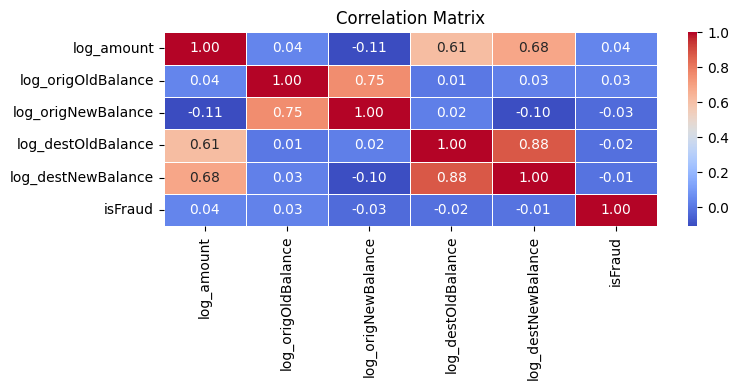

In [ ]:
cols = ['log_amount', 'log_origOldBalance', 'log_origNewBalance', 'log_destOldBalance', 'log_destNewBalance', 'isFraud']

corr_matrix = df[cols].corr()
plt.figure(figsize=(8, 4))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

The high correlation between log_origOldBalance and log_origNewBalance suggests multicollinearity between the two. A similar situation exists for log_destOldBalance and log_destNewBalance. It would be best for us to fix this to reduce noise.

We will create two derived variables: balance_change_origin = log_origNewBalance - log_origOldBalance and balance_change_dest = log_destNewBalance - log_destOldBalance. The pairs don't have the exact same information, so this is more informative than just dropping one.




In [ ]:
df['balance_change_origin'] = df['log_origNewBalance'] - df['log_origOldBalance']
df['balance_change_dest'] = df['log_destNewBalance'] - df['log_destOldBalance']

Let's create some more features using the time-based variables in the dataset:

In [ ]:
def featureEngineering(df):
    df = df.copy()

    #basic time based features:
    df['hour_of_day'] = df['step'] % 24
    df['is_night'] = (df['hour_of_day'] < 6).astype(int)

    #type encoding
    df['original_type'] = df['type'] #for plots
    df = pd.get_dummies(df, columns=['type'], drop_first=True)
    df['is_transfer_like'] = df[['type_TRANSFER', 'type_CASH_OUT']].sum(axis=1).clip(upper=1)

    #track how much of a balance a transaction account was
    df['amount_ratio_to_orig_balance'] = np.exp(df['log_amount']) / (
        np.exp(df['log_amount']) + np.exp(df['balance_change_origin']) + 1e-6
    )

    #check for consistency in balances
    df['origin_balance_error'] = (
        np.exp(df['balance_change_origin']) - np.exp(df['log_amount'])
    ).abs()

    df['dest_balance_error'] = (
        np.exp(df['balance_change_dest']) - np.exp(df['log_amount'])
    ).abs()
    return df

In [ ]:
df = featureEngineering(df)

Before feature selection, we should examine some more parts of our data, especially the newly created features:

In [ ]:
features = [
    'log_amount',
    'origin_balance_error',
    'dest_balance_error',
    'amount_ratio_to_orig_balance',
    'balance_change_origin',
    'balance_change_dest'
]

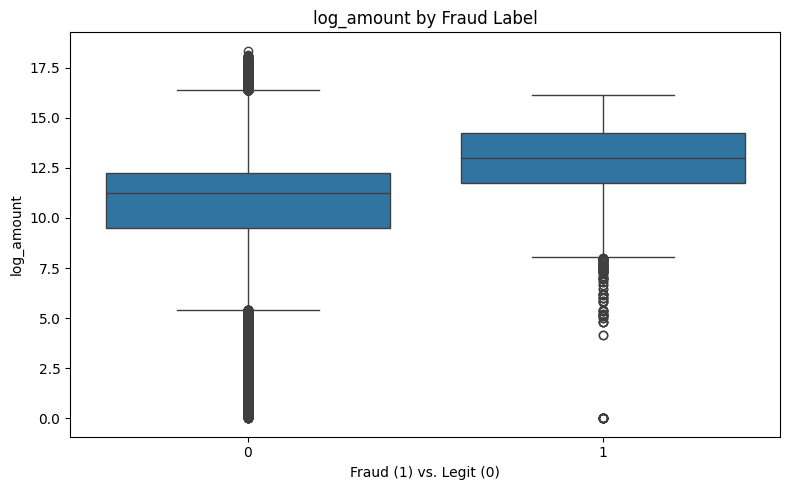

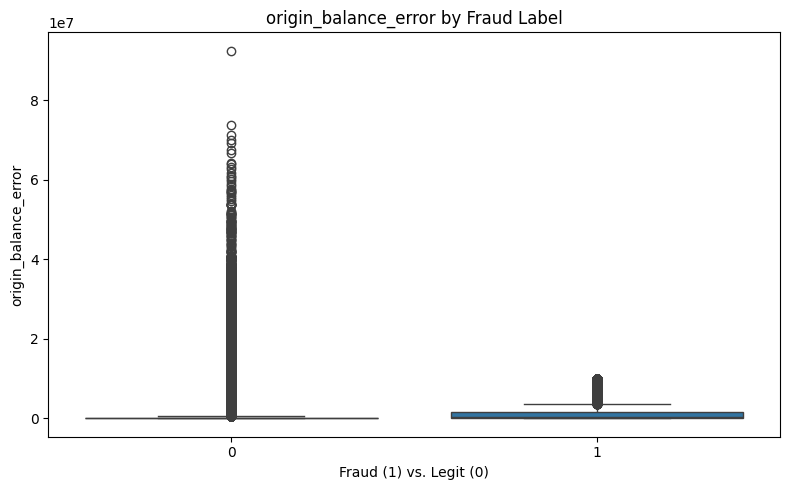

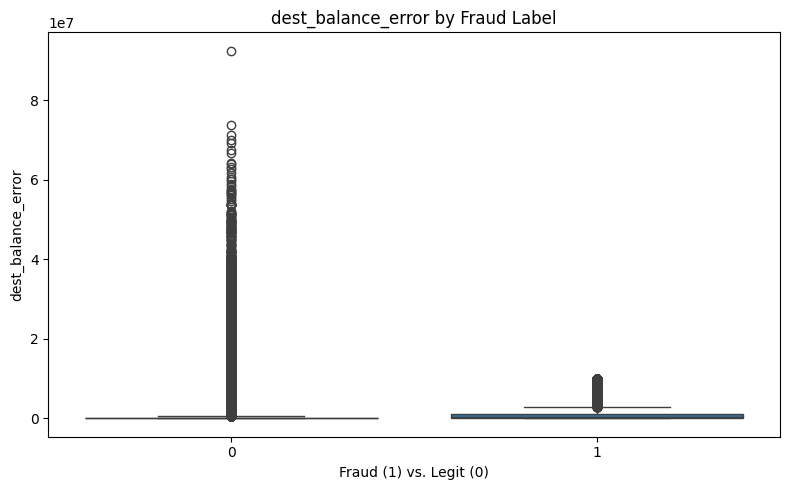

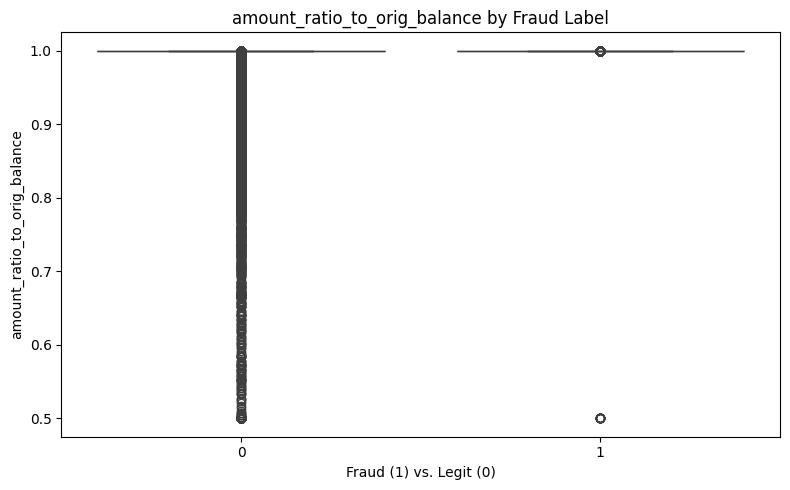

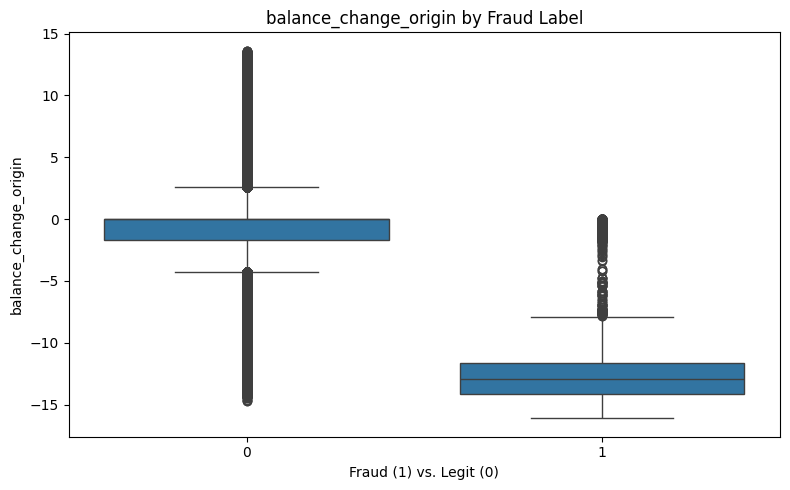

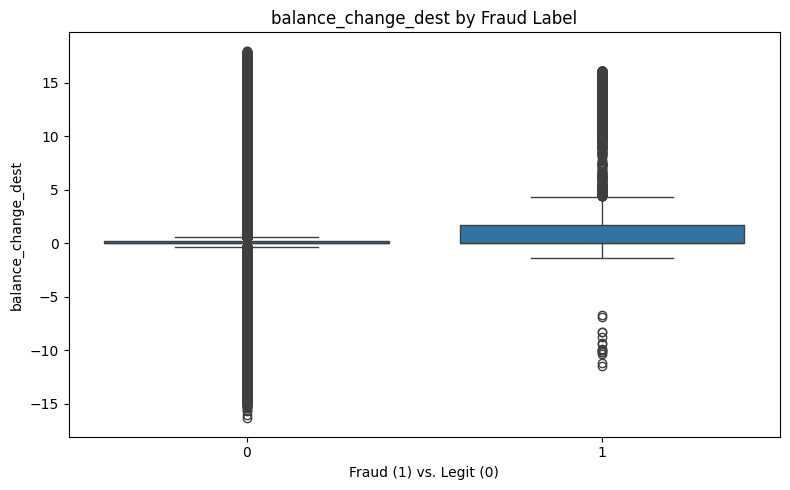

In [ ]:
#boxplot
for feature in features:
    plt.figure(figsize=(8, 5))
    sns.boxplot(x='isFraud', y=feature, data=df)
    plt.title(f'{feature} by Fraud Label')
    plt.xlabel('Fraud (1) vs. Legit (0)')
    plt.ylabel(feature)
    plt.tight_layout()
    plt.show()

Looks like we have a lot of outliers, let's count how many using the IQR method

In [ ]:
for feature in features:
    Q1 = df[feature].quantile(0.25)
    Q3 = df[feature].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    num_outliers = len(df[(df[feature] < lower_bound) | (df[feature] > upper_bound)])
    pct = round(num_outliers / len(df[feature]) * 100, 2)
    print(f"Number of outliers in {feature}: {num_outliers} ({pct}%)")

Number of outliers in log_amount: 32429 (0.51%)
Number of outliers in origin_balance_error: 339158 (5.33%)
Number of outliers in dest_balance_error: 349349 (5.49%)
Number of outliers in amount_ratio_to_orig_balance: 825021 (12.97%)
Number of outliers in balance_change_origin: 1687447 (26.52%)
Number of outliers in balance_change_dest: 1432002 (22.51%)


The number of outliers for log_amount is relatively small. It's also important to note that because this is a fraud detection model, outliers inherently represent important data (i.e. abnormal instances). Removing them could also remove true fraud cases which are already in the minority.

Because of this, rather than directly treating outliers, it could be a better strategy to use a model that is less sensitive to them, such as gradient-boosted trees or random forests.

Next, we'll examine the distribution of these features via histograms:

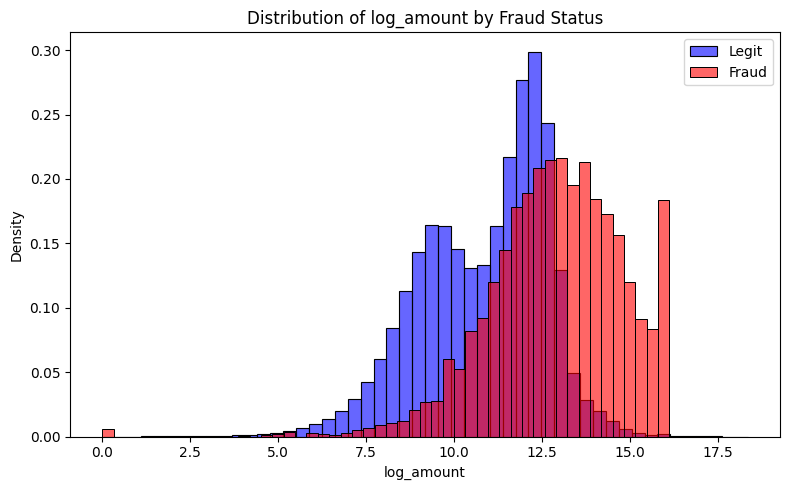

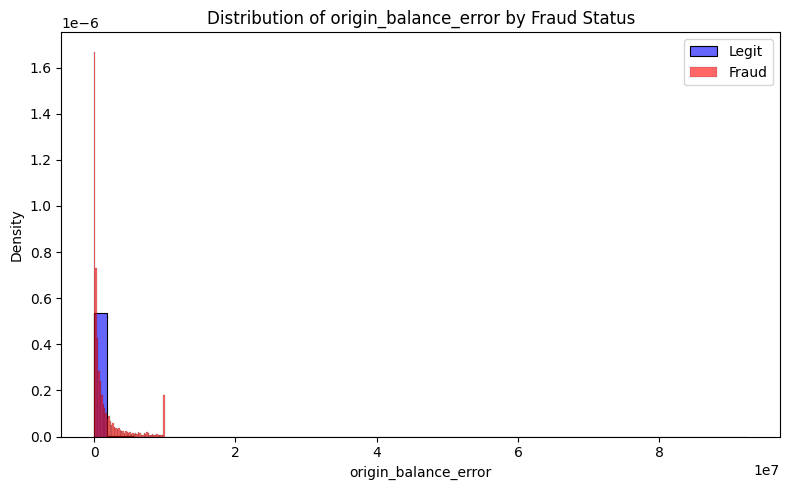

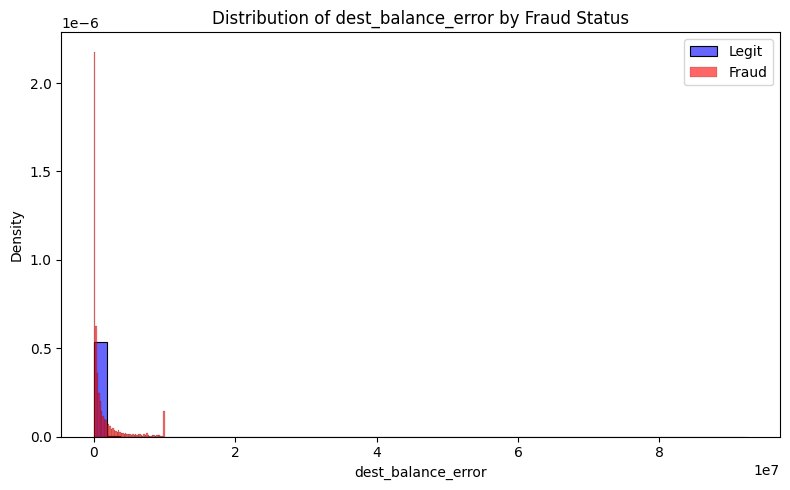

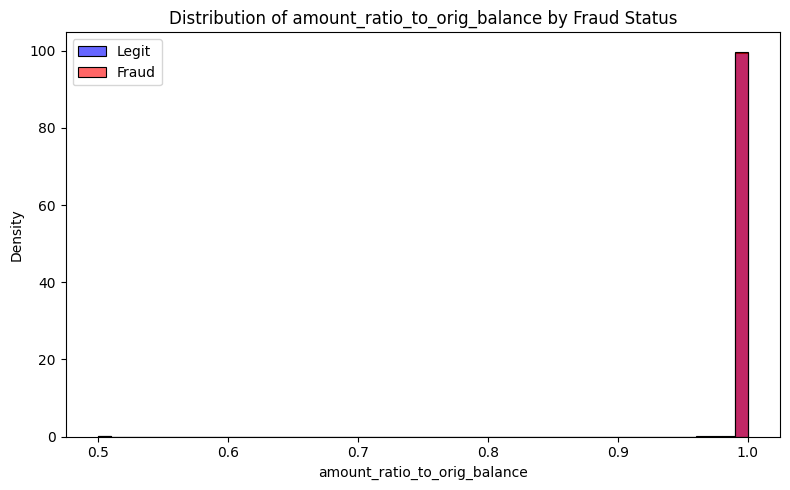

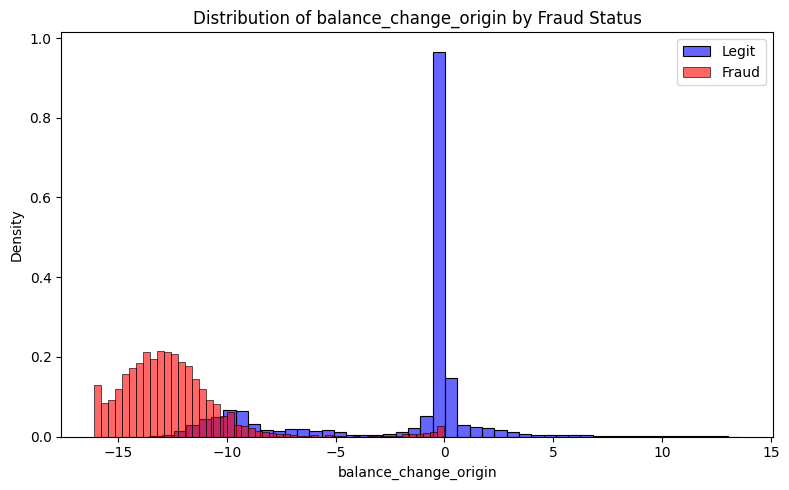

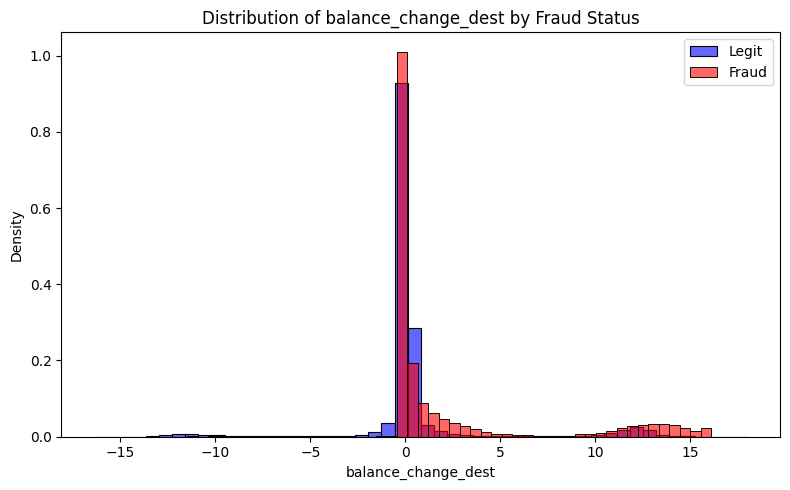

In [ ]:
#histograms
for feature in features:
    plt.figure(figsize=(8, 5))
    sns.histplot(df[df['isFraud'] == 0][feature], bins=50, color='blue', label='Legit', stat='density', alpha=0.6)
    sns.histplot(df[df['isFraud'] == 1][feature], bins=50, color='red', label='Fraud', stat='density', alpha=0.6)
    plt.title(f'Distribution of {feature} by Fraud Status')
    plt.legend()
    plt.xlabel(feature)
    plt.tight_layout()
    plt.show()

We see two trends. One, log_amount and balance_change_origin show a clear distinction between cases of fraud and non-fraud. Intuitively, it makes sense that the cases of fraud are distributed further from the center (i.e. abnormalities). This could be a sign of their predictive power in our modeling.

The second trend is that origin_balance_error, dest_balance_error, and amount_ratio_to_orig_balance are almost entirely concentrated at 0 or 1, with no clear trend between legit/fraud cases. This could be a sign to drop or transform these features.

Balance_change_dest is highly distributed near 0, but is slightly skewed positively for fraudulent cases, while negatively otherwise. This could be a sign of predictive value.

While we're at it, let's look at the skewness for the new features:

In [ ]:
print("\nSkewness:")
print(df[features].skew())


Skewness:
log_amount                      -0.555018
origin_balance_error            30.991784
dest_balance_error              33.157222
amount_ratio_to_orig_balance   -21.062563
balance_change_origin           -1.086306
balance_change_dest              1.673896
dtype: float64


The three features that follow the second trend show high skewness. Because we created them between variables that were already treated logarithmically, further logging would be redundant, so these features will be dropped.

Balance_change_dest is also skewed, but could show a distinction between fraudulent and legit cases (i.e. negative vs positive balance changes), so we will keep that in.

Finally, 'type' is a variable we have largely ignored thus far. Let's examine the distribution of types of transactions according to rates of fraud.

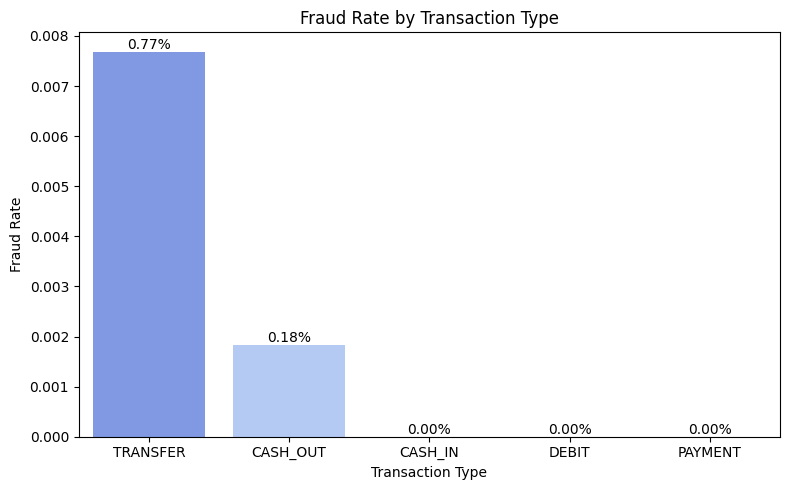

In [ ]:
fraud_rate_by_type = df.groupby('original_type')['isFraud'].mean().sort_values(ascending=False)
plt.figure(figsize=(8, 5))
ax = sns.barplot(x=fraud_rate_by_type.index, y=fraud_rate_by_type.values, hue=fraud_rate_by_type.index, palette='coolwarm', legend=False)
plt.xlabel('Transaction Type')
plt.ylabel('Fraud Rate')
plt.title('Fraud Rate by Transaction Type')
for p in ax.patches:
    height = p.get_height()
    ax.text(p.get_x() + p.get_width() / 2., height,
            f'{height:.2%}', ha='center', va='bottom')

plt.tight_layout()
plt.show()


The is_transfer_like feature we created will be helpful in capturing fraud-related tasks, as they appear to be the vast majority.

Let's address the class imbalance between cases that are/are not fraud (only 0.13% of samples are fraud).

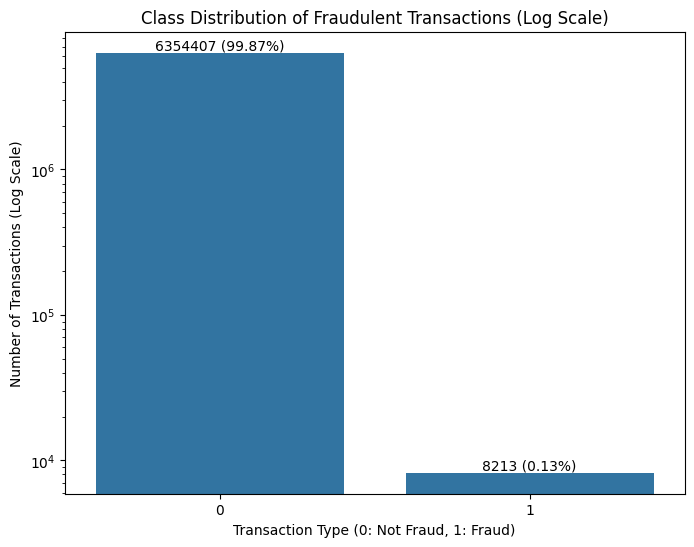

In [ ]:
plt.figure(figsize=(8, 6))
ax = sns.countplot(x='isFraud', data=df)  # Get the axes object
plt.title('Class Distribution of Fraudulent Transactions (Log Scale)')
plt.xlabel('Transaction Type (0: Not Fraud, 1: Fraud)')
plt.ylabel('Number of Transactions (Log Scale)')
plt.yscale('log')

total = len(df)
for p in ax.patches:
    height = p.get_height()
    percentage = f'{height / total * 100:.2f}%'
    ax.text(p.get_x() + p.get_width() / 2., height,
            f'{height:.0f} ({percentage})',
            ha='center', va='bottom')

plt.show()

Our options for "fixing" this are:


1.   Undersample isFraud = 0
2.   Oversample isFraud = 1 (possible with SMOTE)
3.   Apply a greater weight to isFraud = 1 (e.g. set class_weight = balanced)
4.   Stratified train/test splits



1. Undersampling is probably the easiest solution, but will result in a loss of information.
2. Oversampling keeps data, but can be noisy and may result in overfitting.
3. Class weights can work well with certain models (logistic regression, trees) that we are considering. However in extreme cases, possibly including this one, it may not perform as well.
4. A stratified split will only ensure the test set isn't skewed and won't help with training, particularly with such an extreme imbalance.

Overall, for higher recall, SMOTE (oversample) and class weights seem like the best options. Because this is fraud detection, catching more false positives is preferred over missing true positives.

In order to avoid overcorrecting, we will implement class weights first. If it does not perform well (i.e. low recall) after this, we will add in SMOTE. Additionally, we will use stratified splitting when creating our train/test split to ensure the test set is not biased.

This is also a signal to possibly lean towards tree-based models as they are robust to unbalanced data. Logistic regression also supports class weighting.

Class weights: {0: np.float64(0.5006462444095885), 1: np.float64(387.35054182393765)}


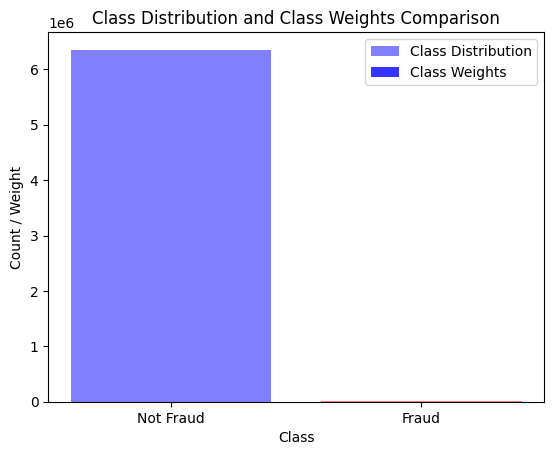

In [ ]:
#see how the class distribution will look after balanced weighting
class_weights = compute_class_weight('balanced', classes=np.array([0, 1]), y=df['isFraud'])
class_weight_dict = {0: class_weights[0], 1: class_weights[1]}
print("Class weights:", class_weight_dict)
plt.bar([0, 1], [df['isFraud'].value_counts()[0], df['isFraud'].value_counts()[1]], color=['blue', 'red'], alpha=0.5, label='Class Distribution')
plt.bar([0, 1], [class_weight_dict[0], class_weight_dict[1]], color=['blue', 'red'], alpha=0.8, label='Class Weights', width=0.3)
plt.xticks([0, 1], ['Not Fraud', 'Fraud'])
plt.xlabel('Class')
plt.ylabel('Count / Weight')
plt.legend()
plt.title('Class Distribution and Class Weights Comparison')
plt.show()

Looks like the fraud cases will be given roughly 387x more weight during training. Again, we will try with just class weights, and then with SMOTE and compare recall.

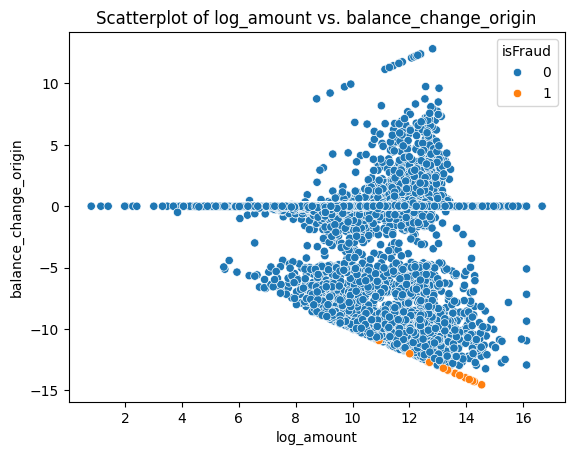

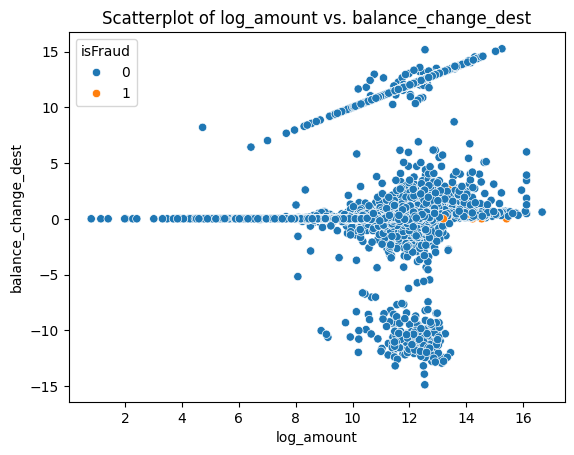

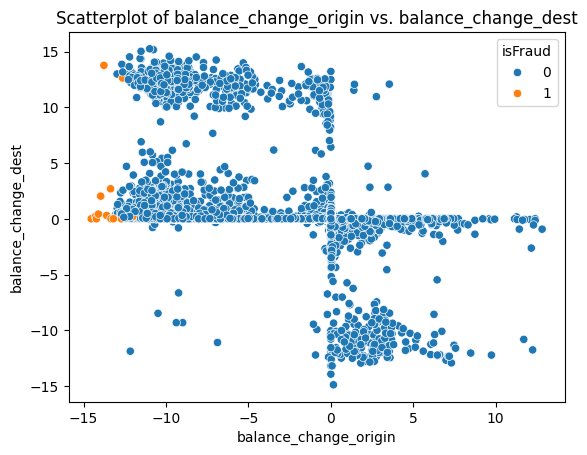

In [ ]:
sample_df = df.sample(n=10000, random_state=42) #sample 10k
#Plot 1: log_amount vs. balance_change_origin
sns.scatterplot(x='log_amount', y='balance_change_origin', hue='isFraud', data=sample_df)
plt.title('Scatterplot of log_amount vs. balance_change_origin')
plt.show()
#Plot 2: log_amount vs. balance_change_dest
sns.scatterplot(x='log_amount', y='balance_change_dest', hue='isFraud', data=sample_df)
plt.title('Scatterplot of log_amount vs. balance_change_dest')
plt.show()
#Plot 3: balance_change_origin vs. balance_change_dest
sns.scatterplot(x='balance_change_origin', y='balance_change_dest', hue='isFraud', data=sample_df)
plt.title('Scatterplot of balance_change_origin vs. balance_change_dest')
plt.show()

Naturally, there are many values of balance_change__ that are 0, so it is tough to see a relationship.

Lastly, let's look at the time-tracking variables: hour_of_day and is_night:

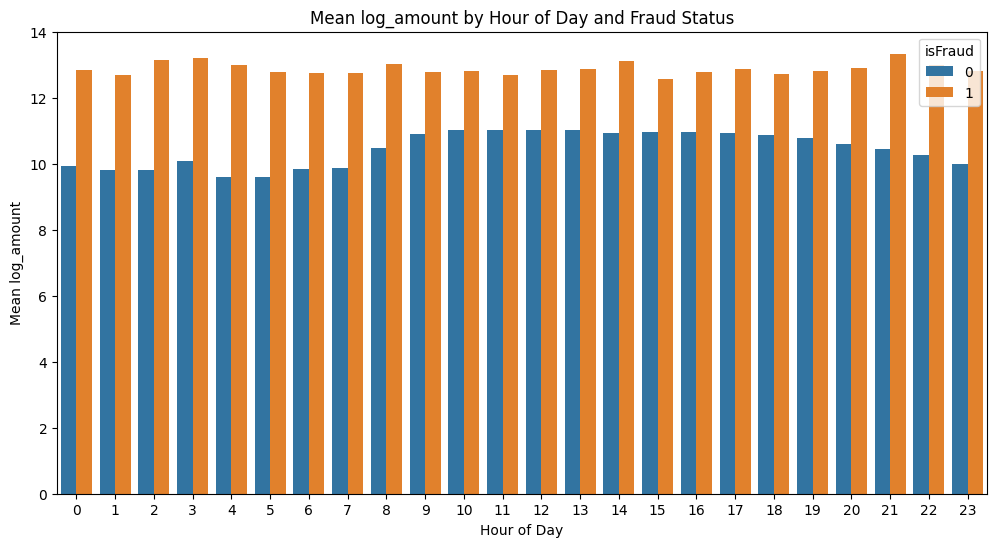

In [ ]:
#trend of log_amount by hour of day/fraud status
hourly_fraud_stats = df.groupby(['hour_of_day', 'isFraud'])['log_amount'].mean().reset_index()
plt.figure(figsize=(12, 6))
sns.barplot(x='hour_of_day', y='log_amount', hue='isFraud', data=hourly_fraud_stats)
plt.title('Mean log_amount by Hour of Day and Fraud Status')
plt.xlabel('Hour of Day')
plt.ylabel('Mean log_amount')
plt.show()

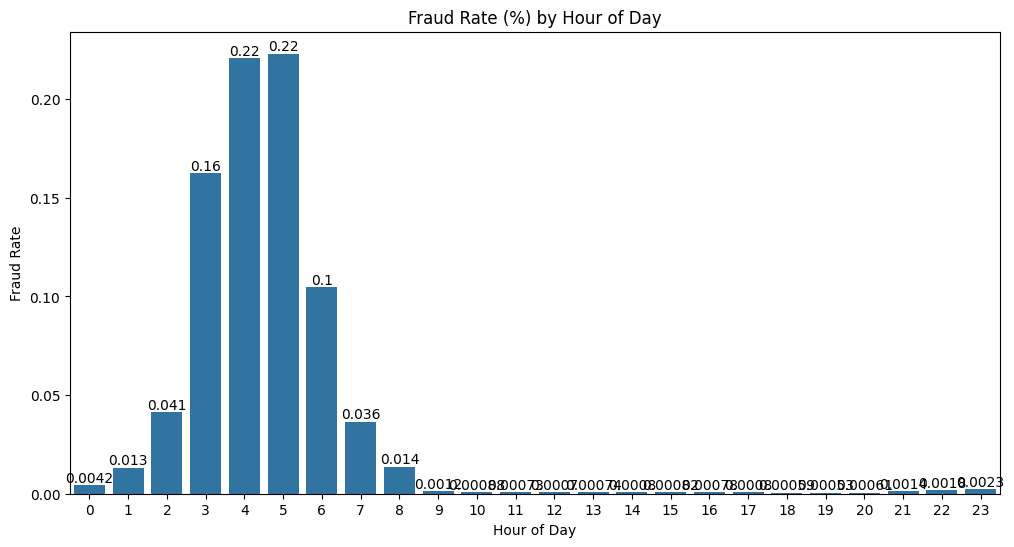

In [ ]:
#fraud rate by hour of day
hourly_fraud_rate = df.groupby('hour_of_day')['isFraud'].mean().reset_index()
plt.figure(figsize=(12, 6))
sns.barplot(x='hour_of_day', y='isFraud', data=hourly_fraud_rate)
plt.title('Fraud Rate (%) by Hour of Day')
plt.xlabel('Hour of Day')
plt.ylabel('Fraud Rate')
for p in plt.gca().patches:
    height = p.get_height()
    plt.gca().text(p.get_x() + p.get_width() / 2., height,
            f'{height:.2}', ha='center', va='bottom')
plt.show()

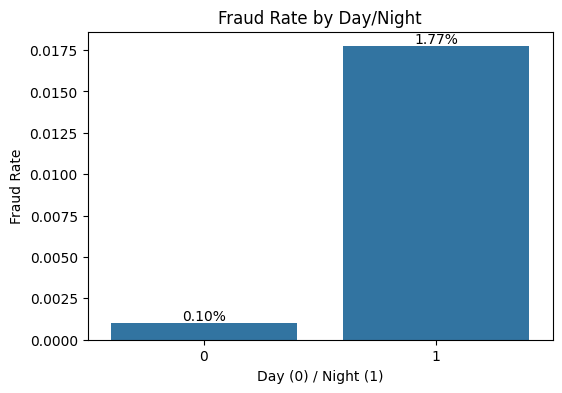

In [ ]:
#fraud rate compared by day/night
day_night_fraud_rate = df.groupby('is_night')['isFraud'].mean().reset_index()
plt.figure(figsize=(6, 4))
sns.barplot(x='is_night', y='isFraud', data=day_night_fraud_rate)
plt.title('Fraud Rate by Day/Night')
plt.xlabel('Day (0) / Night (1)')
plt.ylabel('Fraud Rate')
for p in plt.gca().patches:
    height = p.get_height()
    plt.gca().text(p.get_x() + p.get_width() / 2., height,
            f'{height:.2%}', ha='center', va='bottom')
plt.show()

Having both hour_of_day and is_night would be redundant, since the latter is derived from the former. Additionally, it looks like is_night captures similar information to hour_of_day, which is an increased rate of fraud before 6am. It may be beneficial later on to alter this cutoff based on the  Fraud Rate (%) by Hour of Day plot.

Either way, we will drop hour_of_day and only include is_night.

Our final features are:
1.   log_amount
2.   balance_change_origin (log_origNewBalance - log_origOldBalance)
3.   balance_change_dest (log_origOldBalance - log_origNewBalance)
4.   is_night (if hour_of_day < 6)
5.   is_transfer_like (if type of transaction = TRANSFER or CASH_OUT)
6.   is_first_transaction (if transaction is the customer's first one)


In [ ]:
features = ['log_amount', 'balance_change_origin', 'balance_change_dest',
            'is_night', 'is_transfer_like', 'isFraud'] #isFraud = target variable
data = df[features]
data.head()

,log_amount,balance_change_origin,balance_change_dest,is_night,is_transfer_like,isFraud
0,9.194276,-0.059573,0.000000,1,0,0
1,7.531166,-0.091820,0.000000,1,0,0
2,5.204007,-5.204007,0.000000,1,1,1
3,5.204007,-5.204007,-9.960954,1,1,1
4,9.364703,-0.329599,0.000000,1,0,0


These features were selected based on domain intuition (e.g., high-risk transaction types), re-affirmed by statistical analysis and visual patterns (box plots, histograms, bar charts, correlation matricies). Features that showed predictive signal (i.e. distinction between fraud and legitimate classes) were prioritized. These features were both raw and engineered.

Regarding dropped features, those which showed heavy skew or class imbalance without any distinction between fraud and non-fraud were omitted.

Feature importance will also be further investigated during modeling, and likely lead to another round of omission/selection.

In [ ]:
X = data.drop(columns=['isFraud'])  # Features
y = data['isFraud']  # Target variable

#stratified split to ensure the distribution of 'isFraud' is maintained in both train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(5090096, 5) (1272524, 5) (5090096,) (1272524,)


In [ ]:
#freeing up some ram
del df
del skewed_vars
del features
del file_path
gc.collect()

56775

# **Methodology**

For this fraud detection task, I am evaluating four modeling techniques: **Gradient Boosted Trees, Random Forests, Boosted Trees, and Logistic Regression**. These models were selected and ordered based on their performance characteristics, interpretability, and robustness to the dataset.

**1. Gradient Boosted Trees (GBTs)**

GBTs, particularly XGBoost as will be used here, are highly effective for tabular data and structured problems like fraud detection. They are well suited for mixed feature types (continuous + binary), imbalanced data, and are generally robust to outliers and skew. At the cost of higher variance, they are more fine-tuned and less biased than other models like Random Forests. We will also employ 5-fold cross-validation to determine an optimized threshold for predictions. This will help to offset the imbalanced dataset.

**2. Random Forests**

Random Forests is a strong ensemble method that averages multiple decision trees trained on bootstrapped data. Like GBTs, it is robust to outliers and can handle both numerical and categorical data. Further, it is robust to noise and overfitting, and generally faster to train. This is a method that trades less variance for more bias compared to GBTs. Depending on how the GBT approach performs with threshold optimization, the same method could be applied here.

**3. Boosted Trees**

Boosted trees (AdaBoost) are another approach to decision trees that will mainly serve as a point of comparison with the gradient-based method outlined above. Depending on how the GBT approach performs with threshold optimization, the same method could be applied here.

**4. Logistic Regression**

Logistic Regression offers quick training and easy benchmarking. While it assumes linearity and thus is quite sensitive to skew and outliers, it is still useful for comparison to other models and ensuring they are truly improving performance. We will be using L2 (Ridge) regularization.

**Summary:**
The modeling strategy progresses from complex, high-performing ensemble methods down to simpler, more interpretable baselines. As mentioned, GBTs and Random Forests will show both sides of the bias-variance trade-off, while Boosted Trees and Logistic Regression will serve as simple benchmarks. We also may create an meta model with the best performing techniques.

Due to the severe class imbalance typical in fraud detection (very few fraudulent cases relative to non-fraud), I will start by applying class weighting to penalize misclassifications of the minority class more heavily. If necessary, I will incorporate SMOTE (Synthetic Minority Over-sampling Technique) to further balance the training data by generating synthetic examples of the minority class.

Model performance will be primarily evaluated using F1 score to achieve a balance between false positives and false negatives. Recall, precision, accuracy, and ROC-AUC will also be measured.



#**Gradient Boosted Trees**

Given an imbalanced dataset, we will also attempt to find an optimized threshold using cross-validation

In [ ]:
def train_xgb_cv(X_train, y_train, X_test, y_test, eta=0.1, max_depth=6, min_child_weight=1, n_splits=5, random_state=42):
    pos_weight = np.sum(y_train == 0) / np.sum(y_train == 1) #class weights
    xgb_params = {
        'objective': 'binary:logistic',
        'eval_metric': 'auc',
        'eta': eta,
        'max_depth': max_depth,
        'min_child_weight': min_child_weight,
        'subsample': 0.8,
        'colsample_bytree': 0.8,
        'scale_pos_weight': pos_weight,
        'seed': random_state,
        'tree_method': 'hist'
    }
    print(f"Class distribution in training set: Fraud={sum(y_train == 1)}, Non-fraud={sum(y_train == 0)}")
    print(f"Class weight (scale_pos_weight): {pos_weight:.4f}")
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state) #StratifiedKFold cv
    cv_results, thresholds_per_fold, f1_scores_per_fold, precision_per_fold, recall_per_fold, fpr_per_fold, accuracy_per_fold, roc_auc_per_fold = [], [], [], [], [], [], [], []
    print(f"Starting {n_splits}-fold cross-validation...")
    all_f1_by_threshold = []
    all_precision_by_threshold = []
    all_recall_by_threshold = []
    for fold, (train_idx, val_idx) in enumerate(skf.split(X_train, y_train)):
        print(f"Training fold {fold+1}/{n_splits}")
        X_fold_train, X_fold_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_fold_train, y_fold_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
        dtrain = xgb.DMatrix(X_fold_train, label=y_fold_train)
        dval = xgb.DMatrix(X_fold_val, label=y_fold_val)
        model = xgb.train(
            xgb_params,
            dtrain,
            num_boost_round=300,
            evals=[(dtrain, 'train'), (dval, 'val')],
            early_stopping_rounds=30,
            verbose_eval=50
        )
        y_pred_proba = model.predict(dval)
        sampled_thresholds = np.linspace(0, 1, 200)
        f1_scores = [f1_score(y_fold_val, (y_pred_proba >= threshold).astype(int)) for threshold in sampled_thresholds]
        precision_scores = [precision_score(y_fold_val, (y_pred_proba >= threshold).astype(int), zero_division=0) for threshold in sampled_thresholds]
        recall_scores = [recall_score(y_fold_val, (y_pred_proba >= threshold).astype(int)) for threshold in sampled_thresholds]
        all_f1_by_threshold.append(f1_scores)
        all_precision_by_threshold.append(precision_scores)
        all_recall_by_threshold.append(recall_scores)
        best_threshold = sampled_thresholds[np.argmax(f1_scores)] #best based on f1
        thresholds_per_fold.append(best_threshold)
        y_pred_binary = (y_pred_proba >= best_threshold).astype(int)
        f1 = f1_score(y_fold_val, y_pred_binary)
        precision = precision_score(y_fold_val, y_pred_binary)
        recall = recall_score(y_fold_val, y_pred_binary)
        accuracy = accuracy_score(y_fold_val, y_pred_binary)
        fpr = (y_pred_binary == 1) & (y_fold_val == 0)
        fpr = np.sum(fpr) / np.sum(y_fold_val == 0)
        roc_auc = roc_auc_score(y_fold_val, y_pred_proba)
        fold_results = {
            'fold': fold + 1,
            'best_threshold': best_threshold,
            'f1': f1,
            'precision': precision,
            'recall': recall,
            'accuracy': accuracy,
            'fpr': fpr,
            'roc_auc': roc_auc,
            'model': model
        }
        cv_results.append(fold_results)
        f1_scores_per_fold.append(f1)
        precision_per_fold.append(precision)
        recall_per_fold.append(recall)
        fpr_per_fold.append(fpr)
        accuracy_per_fold.append(accuracy)
        roc_auc_per_fold.append(roc_auc)
        print(f"Fold {fold+1} - F1: {f1:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}, "
              f"Accuracy: {accuracy:.4f}, FPR: {fpr:.4f}, ROC AUC: {roc_auc:.4f}")
    avg_f1 = np.mean(f1_scores_per_fold)
    avg_precision = np.mean(precision_per_fold)
    avg_recall = np.mean(recall_per_fold)
    avg_fpr = np.mean(fpr_per_fold)
    avg_accuracy = np.mean(accuracy_per_fold)
    avg_roc_auc = np.mean(roc_auc_per_fold)
    print("\nCross-validation completed.")
    print(f"Average F1: {avg_f1:.4f}, Average Precision: {avg_precision:.4f}, Average Recall: {avg_recall:.4f}")
    print(f"Average Accuracy: {avg_accuracy:.4f}, Average FPR: {avg_fpr:.4f}, Average ROC AUC: {avg_roc_auc:.4f}")
    best_fold_idx = np.argmax(f1_scores_per_fold)
    best_threshold = thresholds_per_fold[best_fold_idx]
    print(f"\nBest threshold (from fold {best_fold_idx+1}): {best_threshold:.4f}")
    avg_f1_curve = np.mean(all_f1_by_threshold, axis=0)
    avg_precision_curve = np.mean(all_precision_by_threshold, axis=0)
    avg_recall_curve = np.mean(all_recall_by_threshold, axis=0)
    plt.figure(figsize=(10, 6))
    plt.plot(sampled_thresholds, avg_f1_curve, label="F1 Score", linewidth=2)
    plt.plot(sampled_thresholds, avg_precision_curve, label="Precision", linestyle='--')
    plt.plot(sampled_thresholds, avg_recall_curve, label="Recall", linestyle=':')
    best_idx = np.argmax(avg_f1_curve)
    best_thresh = sampled_thresholds[best_idx]
    best_f1 = avg_f1_curve[best_idx]
    plt.scatter([best_thresh], [best_f1], color='red', zorder=5, label=f'Best Threshold = {best_thresh:.3f}')
    plt.xlabel("Threshold")
    plt.ylabel("Score")
    plt.title("Metrics Across Thresholds (Averaged Over Folds)")
    plt.grid(True)
    plt.legend()
    plt.show()
    final_model = cv_results[best_fold_idx]['model']
    return final_model, best_threshold

Class distribution in training set: Fraud=6570, Non-fraud=5083526
Class weight (scale_pos_weight): 773.7482
Starting 5-fold cross-validation...
Training fold 1/5
[0]	train-auc:0.99555	val-auc:0.99615
[50]	train-auc:0.99904	val-auc:0.99899
[100]	train-auc:0.99932	val-auc:0.99915
[150]	train-auc:0.99944	val-auc:0.99920
[200]	train-auc:0.99951	val-auc:0.99922
[242]	train-auc:0.99955	val-auc:0.99922
Fold 1 - F1: 0.7299, Precision: 0.7966, Recall: 0.6735, Accuracy: 0.9994, FPR: 0.0002, ROC AUC: 0.9992
Training fold 2/5
[0]	train-auc:0.99682	val-auc:0.99610
[50]	train-auc:0.99904	val-auc:0.99807
[100]	train-auc:0.99930	val-auc:0.99823
[150]	train-auc:0.99943	val-auc:0.99834
[152]	train-auc:0.99944	val-auc:0.99833
Fold 2 - F1: 0.7292, Precision: 0.8013, Recall: 0.6689, Accuracy: 0.9994, FPR: 0.0002, ROC AUC: 0.9983
Training fold 3/5
[0]	train-auc:0.99706	val-auc:0.99500
[50]	train-auc:0.99902	val-auc:0.99844
[100]	train-auc:0.99931	val-auc:0.99876
[150]	train-auc:0.99943	val-auc:0.99879
[200]

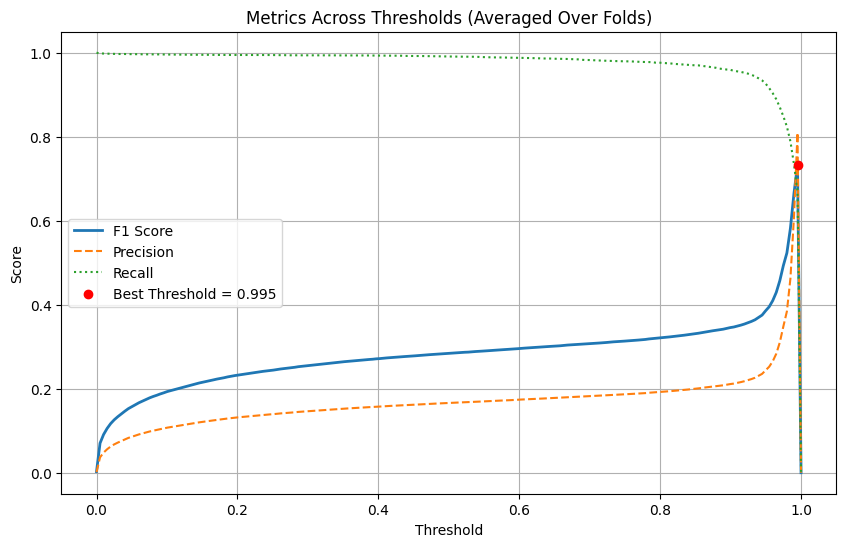

In [ ]:
#find optimal threshold and get best model from CV
GBT_model, optimal_threshold = train_xgb_cv(X_train, y_train, X_test, y_test)

Let's try SMOTE and see how that goes.

Class distribution in training set: Fraud=6570, Non-fraud=5083526
Class weight (scale_pos_weight): 773.7482
Starting 5-fold cross-validation...
Training fold 1/5
[0]	train-auc:0.99555	val-auc:0.99615
[50]	train-auc:0.99904	val-auc:0.99899
[100]	train-auc:0.99932	val-auc:0.99915
[150]	train-auc:0.99944	val-auc:0.99920
[200]	train-auc:0.99951	val-auc:0.99922
[243]	train-auc:0.99955	val-auc:0.99922
Fold 1 - F1: 0.7299, Precision: 0.7966, Recall: 0.6735, Accuracy: 0.9994, FPR: 0.0002, ROC AUC: 0.9992
Training fold 2/5
[0]	train-auc:0.99682	val-auc:0.99610
[50]	train-auc:0.99904	val-auc:0.99807
[100]	train-auc:0.99930	val-auc:0.99823
[150]	train-auc:0.99943	val-auc:0.99834
[152]	train-auc:0.99944	val-auc:0.99833
Fold 2 - F1: 0.7292, Precision: 0.8013, Recall: 0.6689, Accuracy: 0.9994, FPR: 0.0002, ROC AUC: 0.9983
Training fold 3/5
[0]	train-auc:0.99706	val-auc:0.99500
[50]	train-auc:0.99902	val-auc:0.99844
[100]	train-auc:0.99931	val-auc:0.99876
[150]	train-auc:0.99943	val-auc:0.99879
[200]

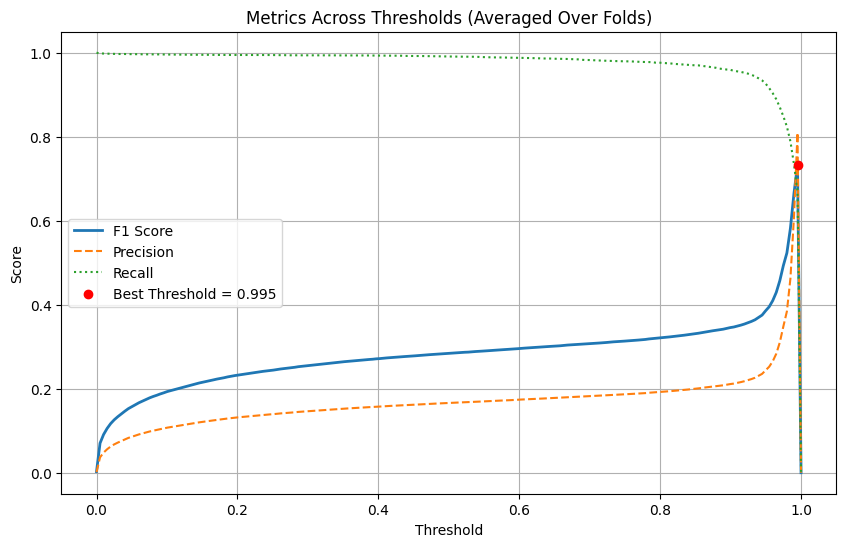

In [ ]:
warnings.filterwarnings("ignore", category=UserWarning, module="threadpoolctl")
def train_xgb_cv_with_smote(X_train, y_train, X_test, y_test, eta=0.1, max_depth=6, min_child_weight=1, n_splits=5, random_state=42):
    xgb_params = {
        'objective': 'binary:logistic',
        'eval_metric': 'auc',
        'eta': eta,
        'max_depth': max_depth,
        'min_child_weight': min_child_weight,
        'subsample': 0.8,
        'colsample_bytree': 0.8,
        'seed': random_state,
        'tree_method': 'hist',
    }
    print(f"Class distribution in training set: Fraud={sum(y_train == 1)}, Non-fraud={sum(y_train == 0)}")
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    cv_results, thresholds_per_fold = [], []
    f1_scores_per_fold, precision_per_fold, recall_per_fold = [], [], []
    fpr_per_fold, accuracy_per_fold, roc_auc_per_fold = [], [], []
    all_f1_by_threshold, all_precision_by_threshold, all_recall_by_threshold = [], [], []
    print(f"Starting {n_splits}-fold cross-validation with SMOTE...")
    for fold, (train_idx, val_idx) in enumerate(skf.split(X_train, y_train)):
        print(f"\nTraining fold {fold+1}/{n_splits}")
        X_fold_train, X_fold_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_fold_train, y_fold_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
        sm = SMOTE(random_state=random_state) #apply SMOTE
        X_resampled, y_resampled = sm.fit_resample(X_fold_train, y_fold_train)
        dtrain = xgb.DMatrix(X_resampled, label=y_resampled)
        dval = xgb.DMatrix(X_fold_val, label=y_fold_val)
        model = xgb.train(
            xgb_params,
            dtrain,
            num_boost_round=300,
            evals=[(dtrain, 'train'), (dval, 'val')],
            early_stopping_rounds=30,
            verbose_eval=50
        )
        y_pred_proba = model.predict(dval)
        sampled_thresholds = np.linspace(0, 1, 200)
        f1_scores = [f1_score(y_fold_val, (y_pred_proba >= t).astype(int)) for t in sampled_thresholds]
        precision_scores = [precision_score(y_fold_val, (y_pred_proba >= t).astype(int), zero_division=0) for t in sampled_thresholds]
        recall_scores = [recall_score(y_fold_val, (y_pred_proba >= t).astype(int)) for t in sampled_thresholds]
        all_f1_by_threshold.append(f1_scores)
        all_precision_by_threshold.append(precision_scores)
        all_recall_by_threshold.append(recall_scores)
        best_threshold = sampled_thresholds[np.argmax(f1_scores)]
        thresholds_per_fold.append(best_threshold)
        y_pred_binary = (y_pred_proba >= best_threshold).astype(int)
        f1 = f1_score(y_fold_val, y_pred_binary)
        precision = precision_score(y_fold_val, y_pred_binary)
        recall = recall_score(y_fold_val, y_pred_binary)
        accuracy = accuracy_score(y_fold_val, y_pred_binary)
        fpr = np.sum((y_pred_binary == 1) & (y_fold_val == 0)) / np.sum(y_fold_val == 0)
        roc_auc = roc_auc_score(y_fold_val, y_pred_proba)
        fold_results = {
            'fold': fold + 1,
            'best_threshold': best_threshold,
            'f1': f1,
            'precision': precision,
            'recall': recall,
            'accuracy': accuracy,
            'fpr': fpr,
            'roc_auc': roc_auc,
            'model': model
        }
        cv_results.append(fold_results)
        f1_scores_per_fold.append(f1)
        precision_per_fold.append(precision)
        recall_per_fold.append(recall)
        fpr_per_fold.append(fpr)
        accuracy_per_fold.append(accuracy)
        roc_auc_per_fold.append(roc_auc)
        print(f"Fold {fold+1} - F1: {f1:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}, "
              f"Accuracy: {accuracy:.4f}, FPR: {fpr:.4f}, ROC AUC: {roc_auc:.4f}")
    avg_f1_curve = np.mean(all_f1_by_threshold, axis=0)
    avg_precision_curve = np.mean(all_precision_by_threshold, axis=0)
    avg_recall_curve = np.mean(all_recall_by_threshold, axis=0)
    best_fold_idx = np.argmax(f1_scores_per_fold)
    best_threshold = thresholds_per_fold[best_fold_idx]
    final_model = cv_results[best_fold_idx]['model']
    print("\nCross-validation completed.")
    print(f"Best threshold from CV: {best_threshold:.4f}")
    plt.figure(figsize=(10, 6))
    plt.plot(sampled_thresholds, avg_f1_curve, label="F1 Score", linewidth=2)
    plt.plot(sampled_thresholds, avg_precision_curve, label="Precision", linestyle='--')
    plt.plot(sampled_thresholds, avg_recall_curve, label="Recall", linestyle=':')
    best_idx = np.argmax(avg_f1_curve)
    best_thresh = sampled_thresholds[best_idx]
    best_f1 = avg_f1_curve[best_idx]
    plt.scatter([best_thresh], [best_f1], color='red', zorder=5, label=f'Best Threshold = {best_thresh:.3f}')
    plt.xlabel("Threshold")
    plt.ylabel("Score")
    plt.title("Metrics Across Thresholds (Averaged Over Folds)")
    plt.grid(True)
    plt.legend()
    plt.show()
    return final_model, best_threshold
GBT_model_SMOTE, optimal_threshold_SMOTE = train_xgb_cv(X_train, y_train, X_test, y_test)

Looks like that didn't change anything, so we'll proceed without SMOTE.

Our optimal threshold is 0.995. This is quite high but makes sense given the severe class imbalance we are dealing with.

Let's train on the full dataset with this threshold.

In [ ]:
def train_GBT(X_train, y_train, eta=0.1, max_depth=6, min_child_weight=1, random_state=42):
    pos_weight = np.sum(y_train == 0) / np.sum(y_train == 1)
    xgb_params = {
        'objective': 'binary:logistic',
        'eval_metric': 'auc',
        'eta': eta,
        'max_depth': max_depth,
        'min_child_weight': min_child_weight,
        'subsample': 0.8,
        'colsample_bytree': 0.8,
        'scale_pos_weight': pos_weight,
        'seed': random_state,
        'tree_method': 'hist'
    }
    print(f"Training GBT model on all data")
    dtrain = xgb.DMatrix(X_train, label=y_train, feature_names=list(X_train.columns))
    final_model = xgb.train(
        xgb_params,
        dtrain,
        num_boost_round=300,
        verbose_eval=50
    )
    print("Final model training completed.")
    return final_model

In [ ]:
optimal_threshold = 0.995 #in case we haven't run CV yet

Training GBT model on all data
Final model training completed.

Final model performance on test set:
F1: 0.7529, Precision: 0.8220, Recall: 0.6945
Accuracy: 0.9994, FPR: 0.0002, ROC AUC: 0.9990

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1270881
           1       0.82      0.69      0.75      1643

    accuracy                           1.00   1272524
   macro avg       0.91      0.85      0.88   1272524
weighted avg       1.00      1.00      1.00   1272524



<Axes: title={'center': 'Feature Importance (Gain)'}, xlabel='Importance score', ylabel='Features'>

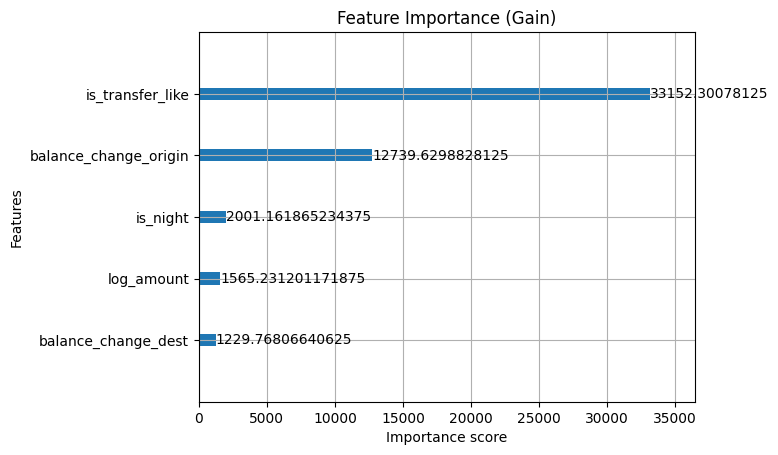

In [ ]:
GBT_model = train_GBT(X_train, y_train) #use optimal threshold from cv
dtest = xgb.DMatrix(X_test, feature_names=list(X_test.columns))
y_test_pred = GBT_model.predict(dtest)
y_test_pred_binary = (y_test_pred >= optimal_threshold).astype(int)
test_f1 = f1_score(y_test, y_test_pred_binary)
test_precision = precision_score(y_test, y_test_pred_binary)
test_recall = recall_score(y_test, y_test_pred_binary)
test_accuracy = accuracy_score(y_test, y_test_pred_binary)
test_fpr = np.sum((y_test_pred_binary == 1) & (y_test == 0)) / np.sum(y_test == 0)
test_roc_auc = roc_auc_score(y_test, y_test_pred)
print("\nFinal model performance on test set:")
print(f"F1: {test_f1:.4f}, Precision: {test_precision:.4f}, Recall: {test_recall:.4f}")
print(f"Accuracy: {test_accuracy:.4f}, FPR: {test_fpr:.4f}, ROC AUC: {test_roc_auc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_test_pred_binary))
xgb.plot_importance(GBT_model, importance_type='gain', title='Feature Importance (Gain)')

The model is clearly choosing to be more cautious rather than over-aggressive in categorizing fraud, as evidenced by the extremely low false positive rate. This is not inherently bad, but could be a point to fine-tune further as there is some breathing room to sacrifice higher FPR in exchange for higher recall.

Overall, the metrics look good, but let's see if we can do any better with some hyperparameter tuning. We'll do a Randomized Search using the param grid detailed below.

In [ ]:
def custom_f1_score(y_true, y_pred_proba, threshold=0.995): #custom scoring to use the optimized threshold
    y_pred = (y_pred_proba >= threshold).astype(int)
    return f1_score(y_true, y_pred)
custom_scorer = make_scorer(custom_f1_score, threshold=0.995)
param_grid = {
    'eta': [0.01, 0.05],
    'max_depth': [8, 10],
    'min_child_weight': [3],
    'gamma': [0, 0.1, 0.3],
    'subsample': [0.6, 0.8],
    'colsample_bytree': [0.6, 0.8],
    'lambda': [1, 5],
    'alpha': [0, 1]
}
xgb_clf = XGBClassifier(
    objective='binary:logistic',
    scale_pos_weight=773.7482,
    eval_metric='auc',
    tree_method='hist',
    device='cpu'
)
search = RandomizedSearchCV(
    estimator=xgb_clf,
    param_distributions=param_grid,
    n_iter=20,
    cv=2,
    scoring=custom_scorer,
    verbose=0,
    random_state=42,
    n_jobs=1
)
search.fit(X_train, y_train)
print("Best Params:", search.best_params_)
print("Best F1 Score at Threshold:", search.best_score_)

Best Params: {'subsample': 0.6, 'min_child_weight': 3, 'max_depth': 10, 'lambda': 5, 'gamma': 0, 'eta': 0.05, 'colsample_bytree': 0.8, 'alpha': 0}
Best F1 Score at Threshold: 0.29779551623377554


Looks like fine tuning didn't make our model any better, so we'll stay with the original hyperparameters we chose (learning rate=0.1, max_depth=6, min_child_weight=1). Additionally, we don't really have a problem with overfitting, so improving generalization with regularization (alpha, lambda, gamma) is not necessary. Further, we included alpha and lambda in our RandomizedSearch and saw no results that would improve the model.

So our final metrics for GBT are:

In [ ]:
GBT_y_test_pred = y_test_pred
GBT_y_test_pred_binary = y_test_pred_binary
GBT_f1 = test_f1
GBT_precision = test_precision
GBT_recall = test_recall
GBT_accuracy = test_accuracy
GBT_fpr = test_fpr
GBT_roc_auc = test_roc_auc
print("\nFinal GBT metrics:")
print(f"F1: {GBT_f1:.4f}, Precision: {GBT_precision:.4f}, Recall: {GBT_recall:.4f}")
print(f"Accuracy: {GBT_accuracy:.4f}, FPR: {GBT_fpr:.4f}, ROC AUC: {GBT_roc_auc:.4f}")


Final GBT metrics:
F1: 0.7529, Precision: 0.8220, Recall: 0.6945
Accuracy: 0.9994, FPR: 0.0002, ROC AUC: 0.9990


In [ ]:
GBT_rmse  = myrmse(GBT_y_test_pred,y_test)
print(f'rmse for GBT is {GBT_rmse}\n')
GBT_rmse_bin  = myrmse(GBT_y_test_pred_binary,y_test)
print(f'rmse for GBT binary is {GBT_rmse_bin}\n')

rmse for GBT is 0.07100000232458115

rmse for GBT binary is 0.024



In [ ]:
print(confusion_matrix(y_test, GBT_y_test_pred_binary))

[[1270634     247]
 [    502    1141]]


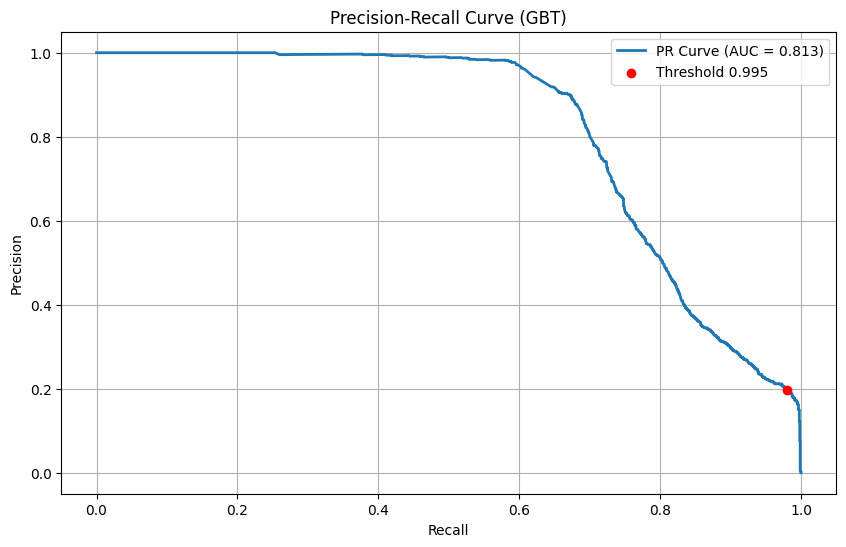

In [ ]:
precision, recall, thresholds = precision_recall_curve(y_test, GBT_y_test_pred)
pr_auc = auc(recall, precision)
threshold_idx = (thresholds >= GBT_f1).argmax() #want to highlight the f1 score
#plot the pr curve
plt.figure(figsize=(10, 6))
plt.plot(recall, precision, label=f'PR Curve (AUC = {pr_auc:.3f})', linewidth=2)
plt.scatter(recall[threshold_idx], precision[threshold_idx], color='red', label=f'Threshold 0.995', zorder=5)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve (GBT)')
plt.grid(True)
plt.legend()
plt.show()

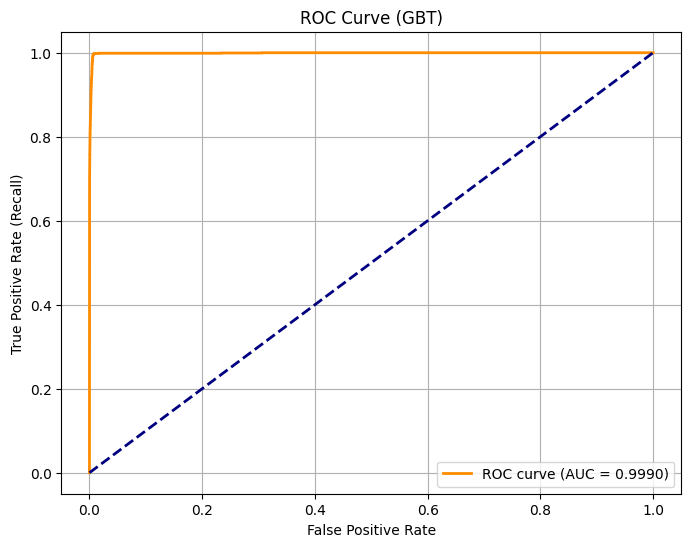

In [ ]:
#roc auc curve
fpr, tpr, _ = roc_curve(y_test, GBT_y_test_pred)
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {GBT_roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve (GBT)')
plt.legend(loc="lower right")
plt.grid()
plt.show()

# **Random Forests**

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done  46 tasks      | elapsed:  3.0min
[Parallel(n_jobs=-1)]: Done 196 tasks      | elapsed: 12.8min
[Parallel(n_jobs=-1)]: Done 446 tasks      | elapsed: 29.5min
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed: 33.1min finished
[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.7s
[Parallel(n_jobs=2)]: Done 196 tasks      | elapsed:    3.2s
[Parallel(n_jobs=2)]: Done 446 tasks      | elapsed:    7.0s
[Parallel(n_jobs=2)]: Done 500 out of 500 | elapsed:    7.9s finished


Best RF Threshold: 0.945, Best F1 Score: 0.8251
Final Random Forest Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00   1270881
           1       0.94      0.74      0.83      1643

    accuracy                           1.00   1272524
   macro avg       0.97      0.87      0.91   1272524
weighted avg       1.00      1.00      1.00   1272524



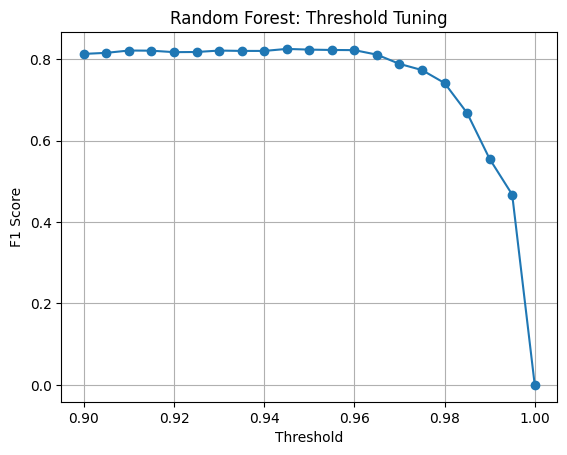

In [ ]:
pos_weight = np.sum(y_train == 0) / np.sum(y_train == 1)
class_weight_dict = {0: 1.0, 1: pos_weight}
RF_model = RandomForestClassifier(
    n_estimators=500,
    max_depth=6,
    min_samples_split=2,
    random_state=42,
    class_weight=class_weight_dict,
    verbose=1,
    n_jobs = -1 #parallel processing
)
RF_model.fit(X_train, y_train)
y_pred_prob_rf = RF_model.predict_proba(X_test)[:, 1]
thresholds_rf = np.arange(0.90, 1.001, 0.005)
f1_scores_rf = []
for threshold in thresholds_rf:
    y_pred_threshold_rf = (y_pred_prob_rf >= threshold).astype(int)
    f1 = f1_score(y_test, y_pred_threshold_rf)
    f1_scores_rf.append(f1)
best_rf_threshold = thresholds_rf[np.argmax(f1_scores_rf)]
print(f"Best RF Threshold: {best_rf_threshold:.3f}, Best F1 Score: {max(f1_scores_rf):.4f}")
final_rf_preds = (y_pred_prob_rf >= best_rf_threshold).astype(int)
print("Final Random Forest Classification Report:\n", classification_report(y_test, final_rf_preds))
plt.plot(thresholds_rf, f1_scores_rf, label="Random Forest", marker='o')
plt.xlabel('Threshold')
plt.ylabel('F1 Score')
plt.title('Random Forest: Threshold Tuning')
plt.grid(True)
plt.show()

Looks great, but recall is one place for improvement. Let's try to deepen our trees to allow more complexity.

In [ ]:
pos_weight = np.sum(y_train == 0) / np.sum(y_train == 1)
class_weight_dict = {0: 1.0, 1: pos_weight}
RF_model_Deeper = RandomForestClassifier(
    n_estimators=500,
    max_depth=None,    #removing max_depth constraint
    min_samples_leaf=1,
    min_samples_split=5,  #increase slightly
    max_features='sqrt',
    bootstrap=True,
    random_state=42,
    class_weight=class_weight_dict,
    verbose=1,
    n_jobs=-1
)
RF_model_Deeper.fit(X_train, y_train)
y_pred_prob_rf = RF_model_Deeper.predict_proba(X_test)[:, 1]
final_rf_preds = (y_pred_prob_rf >= 0.945).astype(int)
print("Final Random Forest Classification Report:\n", classification_report(y_test, final_rf_preds))
rf_precision = precision_score(y_test, final_rf_preds)
rf_recall = recall_score(y_test, final_rf_preds)
rf_f1 = f1_score(y_test, final_rf_preds)
print(f"Precision              : {rf_precision:.4f}")
print(f"Recall                 : {rf_recall:.4f}")
print(f"F1 Score               : {rf_f1:.4f}")

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done  46 tasks      | elapsed:  4.6min
[Parallel(n_jobs=-1)]: Done 196 tasks      | elapsed: 19.6min
[Parallel(n_jobs=-1)]: Done 446 tasks      | elapsed: 43.2min
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed: 48.9min finished
[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    1.1s
[Parallel(n_jobs=2)]: Done 196 tasks      | elapsed:    5.4s
[Parallel(n_jobs=2)]: Done 446 tasks      | elapsed:   11.3s
[Parallel(n_jobs=2)]: Done 500 out of 500 | elapsed:   12.6s finished


Final Random Forest Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00   1270881
           1       1.00      0.64      0.78      1643

    accuracy                           1.00   1272524
   macro avg       1.00      0.82      0.89   1272524
weighted avg       1.00      1.00      1.00   1272524

Precision              : 1.0000
Recall                 : 0.6391
F1 Score               : 0.7798


Looks like that actually didn't help much. Let's just stick with the original model with a max depth of 6.

In [ ]:
rf_y_proba = RF_model.predict_proba(X_test)[:, 1]
rf_y_tuned_pred = (rf_y_proba >= 0.945).astype(int)
RF_accuracy = accuracy_score(y_test, rf_y_tuned_pred)
RF_precision = precision_score(y_test, rf_y_tuned_pred)
RF_recall = recall_score(y_test, rf_y_tuned_pred)
RF_f1 = f1_score(y_test, rf_y_tuned_pred)
RF_roc_auc = roc_auc_score(y_test, rf_y_proba)
RF_avg_precision = average_precision_score(y_test, rf_y_proba)
RF_conf_matrix = confusion_matrix(y_test, rf_y_tuned_pred)
tn, fp, fn, tp = RF_conf_matrix.ravel()
RF_fpr = fp / (fp + tn)
print("Confusion Matrix:")
print(RF_conf_matrix)
print("Classification Report:")
print(classification_report(y_test, rf_y_tuned_pred, digits=4))
print("Overall metrics:")
print(f"Accuracy               : {RF_accuracy:.4f}")
print(f"Precision              : {RF_precision:.4f}")
print(f"Recall                 : {RF_recall:.4f}")
print(f"F1 Score               : {RF_f1:.4f}")
print(f"ROC AUC Score          : {RF_roc_auc:.4f}")
print(f"False positive rate    : {RF_fpr:.4f}")
print(f"Avg Precision (PR AUC) : {RF_avg_precision:.4f}")

[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.7s
[Parallel(n_jobs=2)]: Done 196 tasks      | elapsed:    3.8s
[Parallel(n_jobs=2)]: Done 446 tasks      | elapsed:    7.8s
[Parallel(n_jobs=2)]: Done 500 out of 500 | elapsed:    8.7s finished


Confusion Matrix:
[[1270798      83]
 [    431    1212]]
Classification Report:
              precision    recall  f1-score   support

           0     0.9997    0.9999    0.9998   1270881
           1     0.9359    0.7377    0.8251      1643

    accuracy                         0.9996   1272524
   macro avg     0.9678    0.8688    0.9124   1272524
weighted avg     0.9996    0.9996    0.9996   1272524

Overall metrics:
Accuracy               : 0.9996
Precision              : 0.9359
Recall                 : 0.7377
F1 Score               : 0.8251
ROC AUC Score          : 0.9988
False positive rate    : 0.0001
Avg Precision (PR AUC) : 0.8679


In [ ]:
RF_rmse = myrmse(rf_y_proba, y_test)
print(f'RMSE for Random Forest (probabilities): {RF_rmse:.4f}\n')
RF_rmse_bin = myrmse(rf_y_tuned_pred, y_test)
print(f'RMSE for Random Forest (binary): {RF_rmse_bin:.4f}\n')

RMSE for Random Forest (probabilities): 0.1340

RMSE for Random Forest (binary): 0.0200



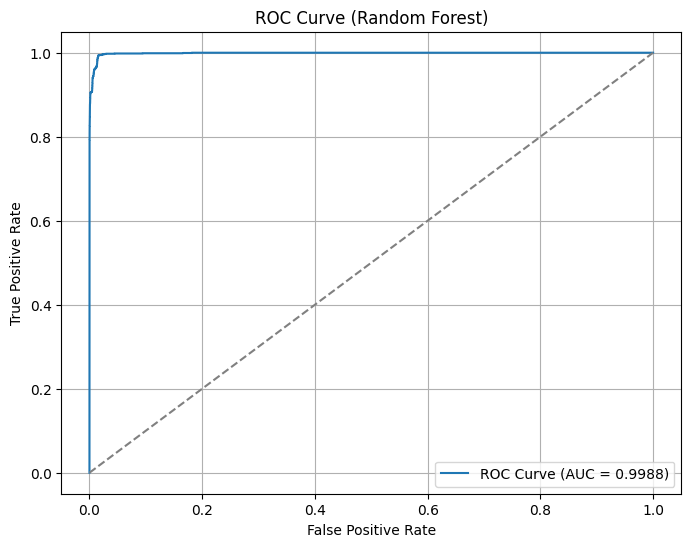

In [ ]:
fpr, tpr, _ = roc_curve(y_test, rf_y_proba)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {RF_roc_auc:.4f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (Random Forest)')
plt.legend()
plt.grid()
plt.show()

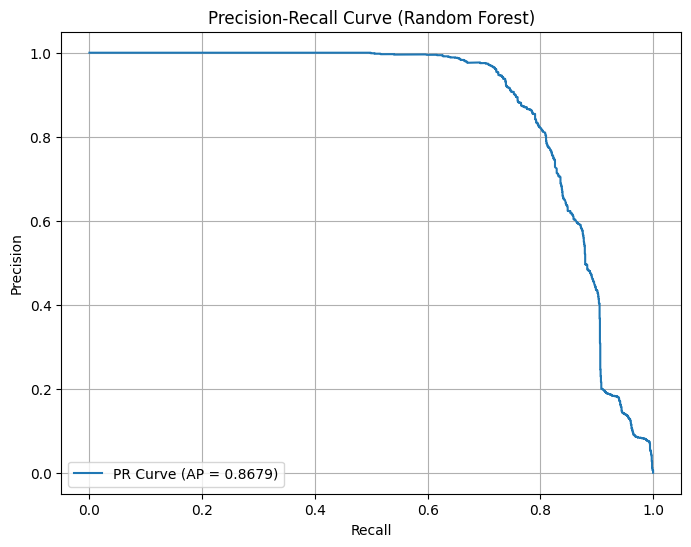

In [ ]:
precisions, recalls, _ = precision_recall_curve(y_test, rf_y_proba)
plt.figure(figsize=(8, 6))
plt.plot(recalls, precisions, label=f'PR Curve (AP = {RF_avg_precision:.4f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve (Random Forest)')
plt.legend()
plt.grid()
plt.show()

# **Boosted Trees**

Training AdaBoost: 100%|██████████| 100/100 [17:19<00:00, 10.40s/it]



Finished training 100 AdaBoost estimators.
Best Threshold: 0.995, Best F1 Score: 0.4273
Final Classification Report:
               precision    recall  f1-score   support

           0     0.9999    0.9970    0.9984   1270881
           1     0.2798    0.9032    0.4273      1643

    accuracy                         0.9969   1272524
   macro avg     0.6399    0.9501    0.7129   1272524
weighted avg     0.9989    0.9969    0.9977   1272524



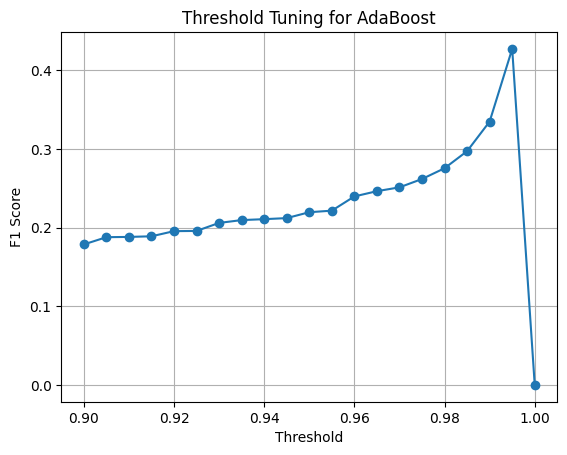

In [ ]:
pos_weight = np.sum(y_train == 0) / np.sum(y_train == 1)
sample_weight = np.where(y_train == 1, pos_weight, 1.0)
sample_weight = sample_weight / sample_weight.sum()  # normalize
base_estimator = DecisionTreeClassifier(max_depth=3)
n_estimators = 100 #just for a baseline to start
learning_rate = 1.0
estimators = []
estimator_weights = []
#manual training loop with tqdm - easier to see progress since it takes so long to run!
for i in tqdm(range(n_estimators), desc="Training AdaBoost"):
    estimator = clone(base_estimator)
    estimator.fit(X_train, y_train, sample_weight=sample_weight)
    y_train_pred = estimator.predict(X_train)
    incorrect = (y_train_pred != y_train).astype(float)
    error = np.dot(sample_weight, incorrect)
    if error <= 0 or error >= 0.5:
        break
    alpha = learning_rate * 0.5 * np.log((1 - error) / error)
    sample_weight *= np.exp(alpha * incorrect)
    sample_weight /= sample_weight.sum()
    estimators.append(estimator)
    estimator_weights.append(alpha)
print(f"\nFinished training {len(estimators)} AdaBoost estimators.")
probs = np.zeros(len(X_test))
for est, alpha in zip(estimators, estimator_weights):
    pred = est.predict(X_test)
    pred = np.where(pred == 1, 1, -1)
    probs += alpha * pred
y_pred_prob = 1 / (1 + np.exp(-2 * probs))  # sigmoid mapping
thresholds = np.arange(0.90, 1.001, 0.005)
f1_scores = []
for threshold in thresholds:
    y_pred = (y_pred_prob >= threshold).astype(int)
    f1 = f1_score(y_test, y_pred)
    f1_scores.append(f1)
best_threshold = thresholds[np.argmax(f1_scores)]
print(f"Best Threshold: {best_threshold:.3f}, Best F1 Score: {max(f1_scores):.4f}")
final_preds = (y_pred_prob >= best_threshold).astype(int)
print("Final Classification Report:\n", classification_report(y_test, final_preds, digits=4))
plt.plot(thresholds, f1_scores, marker='o')
plt.xlabel('Threshold')
plt.ylabel('F1 Score')
plt.title('Threshold Tuning for AdaBoost')
plt.grid(True)
plt.show()

Recall is good but precision is definitely not. Let's increase to 300 estimators and also bump up our learning rate a bit

In [ ]:
pos_weight = np.sum(y_train == 0) / np.sum(y_train == 1)
sample_weight = np.where(y_train == 1, pos_weight, 1.0)
sample_weight = sample_weight / sample_weight.sum()  # normalize
base_estimator = DecisionTreeClassifier(max_depth=3)
n_estimators = 300
learning_rate = 1.01
estimators = []
estimator_weights = []
for i in tqdm(range(n_estimators), desc="Training AdaBoost"):
    estimator = clone(base_estimator)
    estimator.fit(X_train, y_train, sample_weight=sample_weight)
    y_train_pred = estimator.predict(X_train)
    incorrect = (y_train_pred != y_train).astype(float)
    error = np.dot(sample_weight, incorrect)
    if error <= 0 or error >= 0.5:
        break
    alpha = learning_rate * 0.5 * np.log((1 - error) / error)
    sample_weight *= np.exp(alpha * incorrect)
    sample_weight /= sample_weight.sum()
    estimators.append(estimator)
    estimator_weights.append(alpha)
print(f"\nFinished training {len(estimators)} AdaBoost estimators.")
probs = np.zeros(len(X_test))
for est, alpha in zip(estimators, estimator_weights):
    pred = est.predict(X_test)
    pred = np.where(pred == 1, 1, -1)
    probs += alpha * pred
y_pred_prob = 1 / (1 + np.exp(-2 * probs))  #sigmoid
final_preds = (y_pred_prob >= 0.995).astype(int)
print("Final Classification Report:\n", classification_report(y_test, final_preds, digits=4))

Training AdaBoost: 100%|██████████| 300/300 [59:24<00:00, 11.88s/it]



Finished training 300 AdaBoost estimators.
Final Classification Report:
               precision    recall  f1-score   support

           0     0.9999    0.9975    0.9987   1270881
           1     0.3339    0.9544    0.4947      1643

    accuracy                         0.9975   1272524
   macro avg     0.6669    0.9759    0.7467   1272524
weighted avg     0.9991    0.9975    0.9981   1272524



In [ ]:
BOOST_accuracy = accuracy_score(y_test, final_preds)
BOOST_precision = precision_score(y_test, final_preds)
BOOST_recall = recall_score(y_test, final_preds)
BOOST_f1 = f1_score(y_test, final_preds)
BOOST_roc_auc = roc_auc_score(y_test, y_pred_prob)
BOOST_avg_precision = average_precision_score(y_test, y_pred_prob)
BOOST_conf_matrix = confusion_matrix(y_test, final_preds)
tn, fp, fn, tp = BOOST_conf_matrix.ravel()
BOOST_fpr = fp / (fp + tn)
print("Confusion Matrix:")
print(BOOST_conf_matrix)
print("Final Classification Report:\n", classification_report(y_test, final_preds))
print("Overall metrics:")
print(f"Accuracy               : {BOOST_accuracy:.4f}")
print(f"Precision              : {BOOST_precision:.4f}")
print(f"Recall                 : {BOOST_recall:.4f}")
print(f"F1 Score               : {BOOST_f1:.4f}")
print(f"ROC AUC Score          : {BOOST_roc_auc:.4f}")
print(f"Avg Precision (PR AUC) : {BOOST_avg_precision:.4f}")
print(f"False Positive Rate    : {BOOST_fpr:.4f}")

Confusion Matrix:
[[1267753    3128]
 [     75    1568]]
Final Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00   1270881
           1       0.33      0.95      0.49      1643

    accuracy                           1.00   1272524
   macro avg       0.67      0.98      0.75   1272524
weighted avg       1.00      1.00      1.00   1272524

Overall metrics:
Accuracy               : 0.9975
Precision              : 0.3339
Recall                 : 0.9544
F1 Score               : 0.4947
ROC AUC Score          : 0.9994
Avg Precision (PR AUC) : 0.8927
False Positive Rate    : 0.0025


In [ ]:
BOOST_rmse_prob = myrmse(y_test, y_pred_prob)
print(f'RMSE (probabilities): {BOOST_rmse_prob:.4f}')
BOOST_rmse_bin = myrmse(y_test, y_pred_prob)
print(f'RMSE (binary): {BOOST_rmse_bin:.4f}')

RMSE (probabilities): 0.1030
RMSE (binary): 0.1030


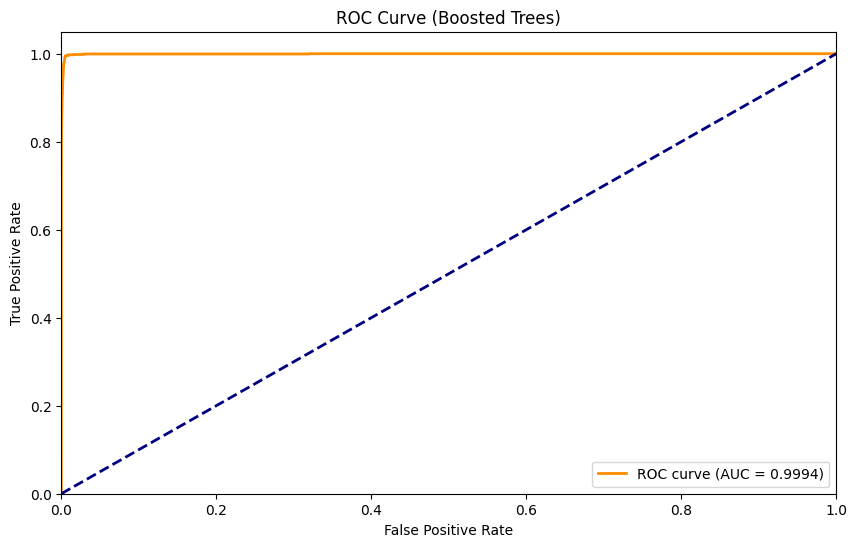

In [ ]:
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
roc_auc_value = auc(fpr, tpr)
precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_pred_prob)
pr_auc_value = auc(recall_vals, precision_vals)
plt.figure(figsize=(10, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc_value:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (Boosted Trees)')
plt.legend(loc="lower right")
plt.show()

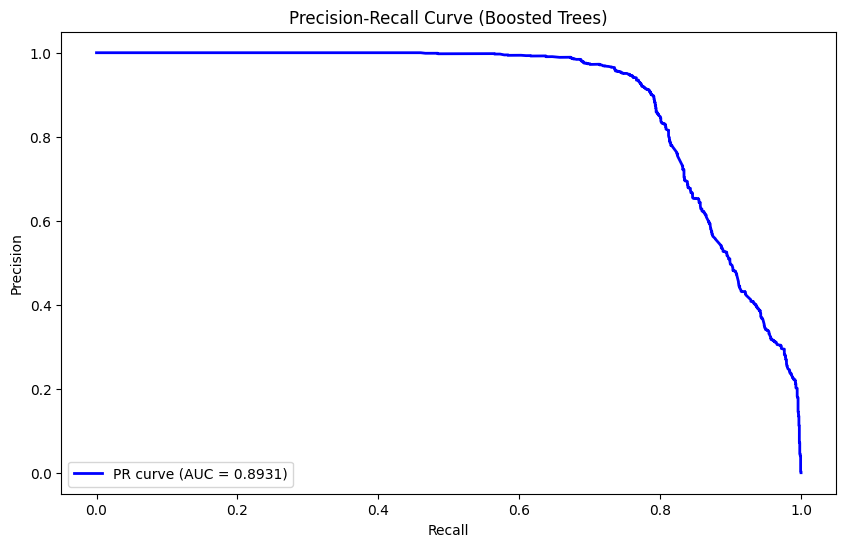

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(recall_vals, precision_vals, color='b', lw=2, label=f'PR curve (AUC = {pr_auc_value:.4f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve (Boosted Trees)')
plt.legend(loc="lower left")
plt.show()

#**Logistic Regression**

In [ ]:
#scale features first
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
pos_weight = np.sum(y_train == 0) / np.sum(y_train == 1)
class_weight_dict = {0: 1.0, 1: pos_weight}
#train
LOGR_model = LogisticRegression(
    penalty='l2',
    C=1.0,
    class_weight=class_weight_dict,
    solver='liblinear',
    max_iter=1000
)
LOGR_model.fit(X_train_scaled, y_train)
y_pred = LOGR_model.predict(X_test_scaled)
y_proba = LOGR_model.predict_proba(X_test_scaled)[:, 1]
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_proba)
avg_precision = average_precision_score(y_test, y_proba)
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("Classification Report:")
print(classification_report(y_test, y_pred, digits=4))
print("Overall metrics:")
print(f"Accuracy               : {accuracy:.4f}")
print(f"Precision              : {precision:.4f}")
print(f"Recall                 : {recall:.4f}")
print(f"F1 Score               : {f1:.4f}")
print(f"ROC AUC Score          : {roc_auc:.4f}")
print(f"Avg Precision (PR AUC) : {avg_precision:.4f}")

Confusion Matrix:
[[1095866  175015]
 [     38    1605]]
Classification Report:
              precision    recall  f1-score   support

           0     1.0000    0.8623    0.9260   1270881
           1     0.0091    0.9769    0.0180      1643

    accuracy                         0.8624   1272524
   macro avg     0.5045    0.9196    0.4720   1272524
weighted avg     0.9987    0.8624    0.9249   1272524

Overall metrics:
Accuracy               : 0.8624
Precision              : 0.0091
Recall                 : 0.9769
F1 Score               : 0.0180
ROC AUC Score          : 0.9836
Avg Precision (PR AUC) : 0.3436


Let's try with the 0.995 threshold we got from the GBT cross-validation.

In [ ]:
LOGR_y_proba = LOGR_model.predict_proba(X_test_scaled)[:, 1]
#let's try the threshold we got from the GBT CV
threshold = 0.995
LOGR_y_tuned_pred = (LOGR_y_proba >= threshold).astype(int)
LOGR_accuracy = accuracy_score(y_test, LOGR_y_tuned_pred)
LOGR_precision = precision_score(y_test, LOGR_y_tuned_pred)
LOGR_recall = recall_score(y_test, LOGR_y_tuned_pred)
LOGR_f1 = f1_score(y_test, LOGR_y_tuned_pred)
LOGR_roc_auc = roc_auc_score(y_test, LOGR_y_proba)
LOGR_avg_precision = average_precision_score(y_test, LOGR_y_proba)
tn, fp, fn, tp = confusion_matrix(y_test, LOGR_y_tuned_pred).ravel()
LOGR_fpr = fp / (fp + tn)
print("Confusion Matrix:")
print(confusion_matrix(y_test, LOGR_y_tuned_pred))
print("Classification Report:")
print(classification_report(y_test, LOGR_y_tuned_pred, digits=4))
print("Overall metrics:")
print(f"Accuracy               : {LOGR_accuracy:.4f}")
print(f"Precision              : {LOGR_precision:.4f}")
print(f"Recall                 : {LOGR_recall:.4f}")
print(f"F1 Score               : {LOGR_f1:.4f}")
print(f"ROC AUC Score          : {LOGR_roc_auc:.4f}")
print(f"False positive rate    : {LOGR_fpr:.4f}")
print(f"Avg Precision (PR AUC) : {LOGR_avg_precision:.4f}")

Confusion Matrix:
[[1270562     319]
 [   1309     334]]
Classification Report:
              precision    recall  f1-score   support

           0     0.9990    0.9997    0.9994   1270881
           1     0.5115    0.2033    0.2909      1643

    accuracy                         0.9987   1272524
   macro avg     0.7552    0.6015    0.6452   1272524
weighted avg     0.9983    0.9987    0.9984   1272524

Overall metrics:
Accuracy               : 0.9987
Precision              : 0.5115
Recall                 : 0.2033
F1 Score               : 0.2909
ROC AUC Score          : 0.9836
False positive rate    : 0.0003
Avg Precision (PR AUC) : 0.3436


In [ ]:
LOGR_rmse = myrmse(LOGR_y_proba, y_test)
print(f'RMSE for Logistic Regression (probabilities): {LOGR_rmse:.4f}\n')
LOGR_rmse_bin = myrmse(LOGR_y_tuned_pred, y_test)
print(f'RMSE for Logistic Regression (binary): {LOGR_rmse_bin:.4f}\n')

RMSE for Logistic Regression (probabilities): 0.2770

RMSE for Logistic Regression (binary): 0.0360



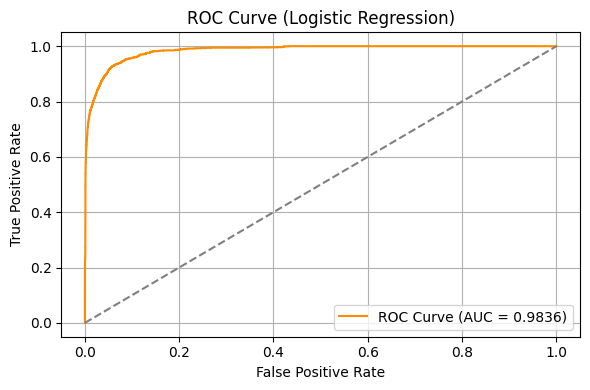

In [ ]:
LOGR_fpr, LOGR_tpr, LOGR_thresholds = roc_curve(y_test, y_proba)
plt.figure(figsize=(6, 4))
plt.plot(LOGR_fpr, LOGR_tpr, label=f"ROC Curve (AUC = {LOGR_roc_auc:.4f})", color='darkorange')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Logistic Regression)")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()

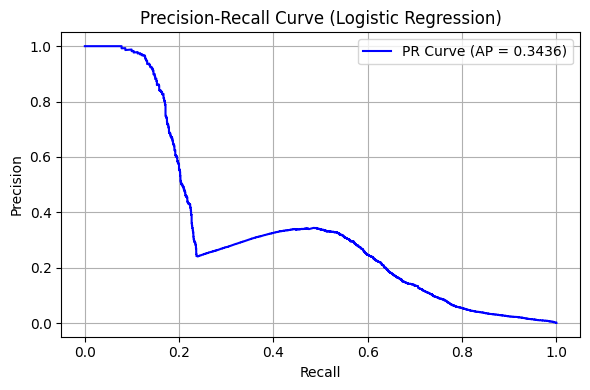

In [ ]:
logreg_y_proba = LOGR_model.predict_proba(X_test_scaled)[:, 1]
LOGR_precision, LOGR_recall, _ = precision_recall_curve(y_test, logreg_y_proba)
LOGR_avg_precision = average_precision_score(y_test, logreg_y_proba)
plt.figure(figsize=(6, 4))
plt.plot(LOGR_recall, LOGR_precision, label=f"PR Curve (AP = {LOGR_avg_precision:.4f})", color='blue')
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve (Logistic Regression)")
plt.legend(loc="upper right")
plt.grid(True)
plt.tight_layout()
plt.show()

Still not great, but better than before. Didn't expect anything fantastic from a linear model anyways.

# **Meta Model**

In [ ]:
dtest = xgb.DMatrix(X_test, feature_names=list(X_test.columns))
rf_test_preds = RF_model.predict_proba(X_test)[:, 1]
gbt_test_preds = GBT_model.predict(dtest, output_margin=False)

rf_train_preds = RF_model.predict_proba(X_train)[:, 1]
gbt_train_preds = GBT_model.predict(xgb.DMatrix(X_train, feature_names=list(X_train.columns)))

X_meta_test = np.column_stack((rf_test_preds, gbt_test_preds))

[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.8s
[Parallel(n_jobs=2)]: Done 196 tasks      | elapsed:    3.2s
[Parallel(n_jobs=2)]: Done 446 tasks      | elapsed:    7.1s
[Parallel(n_jobs=2)]: Done 500 out of 500 | elapsed:    7.9s finished
[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    3.6s
[Parallel(n_jobs=2)]: Done 196 tasks      | elapsed:   15.8s
[Parallel(n_jobs=2)]: Done 446 tasks      | elapsed:   36.5s
[Parallel(n_jobs=2)]: Done 500 out of 500 | elapsed:   40.6s finished


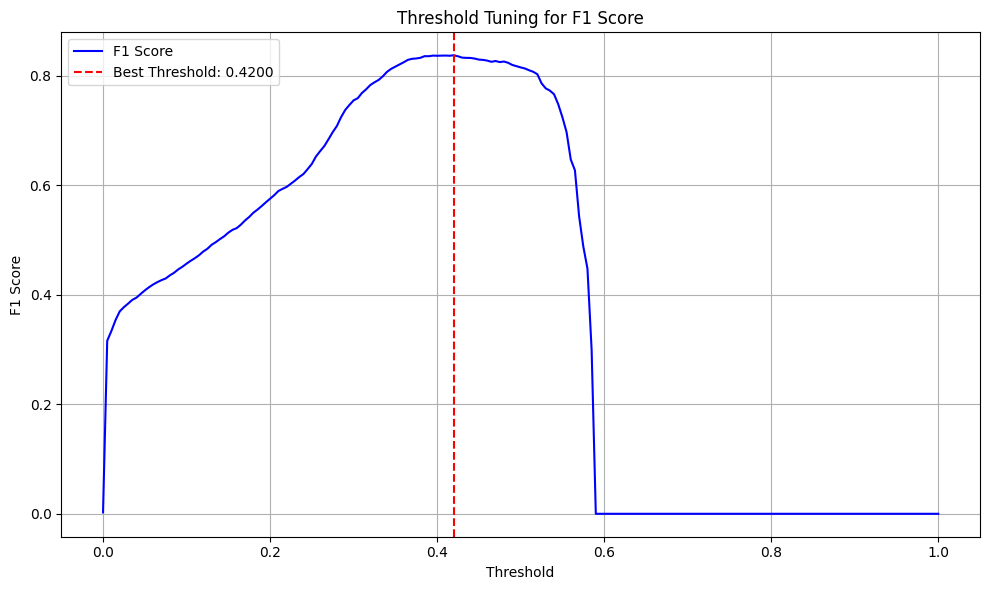

Best Threshold 0.4200 with F1 score: 0.8375


In [ ]:
meta_model = LogisticRegression()
X_meta_train = np.column_stack((rf_train_preds, gbt_train_preds))
meta_model.fit(X_meta_train, y_train)
final_preds_prob = meta_model.predict_proba(X_meta_test)[:, 1]
thresholds = np.arange(0, 1.005, 0.005)
f1_scores = []
best_f1 = 0
best_threshold = 0

for threshold in thresholds:
    final_preds = (final_preds_prob >= threshold).astype(int)
    f1 = f1_score(y_test, final_preds)
    f1_scores.append(f1)
    if f1 > best_f1:
        best_f1 = f1
        best_threshold = threshold

plt.figure(figsize=(10, 6))
plt.plot(thresholds, f1_scores, label="F1 Score", color='blue')
plt.axvline(x=best_threshold, color='red', linestyle='--', label=f'Best Threshold: {best_threshold:.4f}')
plt.xlabel('Threshold')
plt.ylabel('F1 Score')
plt.title('Threshold Tuning for F1 Score')
plt.legend(loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()

print(f"Best Threshold {best_threshold:.4f} with F1 score: {best_f1:.4f}")

Let's see if creating our own manual weighted average will do any better.

In [ ]:
best_f1 = 0
best_weight = 0
best_threshold = 0

for weight in tqdm(np.arange(0, 1.01, 0.05)):
    combined_preds = weight * rf_test_preds + (1-weight) * gbt_test_preds

    # Find best threshold for this weight
    for threshold in np.arange(0, 1.005, 0.005):
        final_preds = (combined_preds >= threshold).astype(int)
        f1 = f1_score(y_test, final_preds)

        if f1 > best_f1:
            best_f1 = f1
            best_weight = weight
            best_threshold = threshold

print(f"Best weight: {best_weight}, Best threshold: {best_threshold}, F1: {best_f1}")

100%|██████████| 21/21 [04:29<00:00, 12.85s/it]

Best weight: 0.2, Best threshold: 0.975, F1: 0.8407050216162288


Let's fine tune a bit further to optimize as much as we can

In [ ]:
best_f1 = 0
best_weight = 0
best_threshold = 0

for weight in tqdm(np.arange(0.15, 0.25, 0.001)):  # Around 0.2
    combined_preds = weight * rf_test_preds + (1-weight) * gbt_test_preds

    for threshold in np.arange(0.95, 1.001, 0.001):  # Around 0.975
        final_preds = (combined_preds >= threshold).astype(int)
        f1 = f1_score(y_test, final_preds)

        if f1 > best_f1:
            best_f1 = f1
            best_weight = weight
            best_threshold = threshold

print(f"Best weight: {best_weight}, Best threshold: {best_threshold}, F1: {best_f1}")

100%|██████████| 100/100 [05:29<00:00,  3.29s/it]

Best weight: 0.23100000000000007, Best threshold: 0.973, F1: 0.84214024592888


In [ ]:
best_weight = 0.23100000000000007
best_threshold = 0.973

In [ ]:
from sklearn.metrics import roc_auc_score

combined_preds_prob = best_weight * rf_test_preds + (1 - best_weight) * gbt_test_preds
final_preds_prob = combined_preds_prob  #probability predictions
final_preds = (combined_preds_prob >= best_threshold).astype(int)  #binary predictions

META_accuracy = accuracy_score(y_test, final_preds)
META_precision = precision_score(y_test, final_preds)
META_recall = recall_score(y_test, final_preds)
META_f1 = f1_score(y_test, final_preds)
META_roc_auc = roc_auc_score(y_test, final_preds_prob)
META_conf_matrix = confusion_matrix(y_test, final_preds)
tn, fp, fn, tp = META_conf_matrix.ravel()
META_fpr = fp / (fp + tn)
print(f"Threshold: {best_threshold:.4f}")
print(f"F1 Score: {META_f1:.4f}")
print(f"Precision: {META_precision:.4f}")
print(f"Recall: {META_recall:.4f}")
print(f"Accuracy: {META_accuracy:.4f}")
print(f"ROC AUC: {META_roc_auc:.4f}")
print(f"False Positive Rate: {META_fpr:.4f}")
print("Confusion Matrix:")
print(META_conf_matrix)
print("Classification Report:")
print(classification_report(y_test, final_preds, digits=4))

Threshold: 0.9730
F1 Score: 0.8421
Precision: 0.9275
Recall: 0.7712
Accuracy: 0.9996
ROC AUC: 0.9994
False Positive Rate: 0.0001
Confusion Matrix:
[[1270782      99]
 [    376    1267]]
Classification Report:
              precision    recall  f1-score   support

           0     0.9997    0.9999    0.9998   1270881
           1     0.9275    0.7712    0.8421      1643

    accuracy                         0.9996   1272524
   macro avg     0.9636    0.8855    0.9210   1272524
weighted avg     0.9996    0.9996    0.9996   1272524



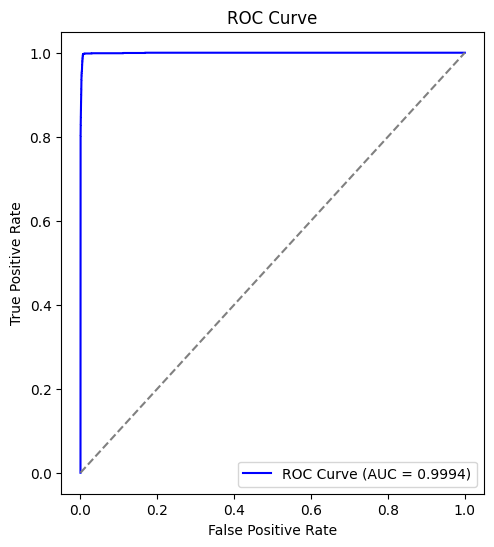

In [ ]:
# ROC curve
fpr_roc, tpr_roc, _ = roc_curve(y_test, final_preds_prob)
roc_auc_score = auc(fpr_roc, tpr_roc)

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(fpr_roc, tpr_roc, color='blue', label=f'ROC Curve (AUC = {roc_auc_score:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()

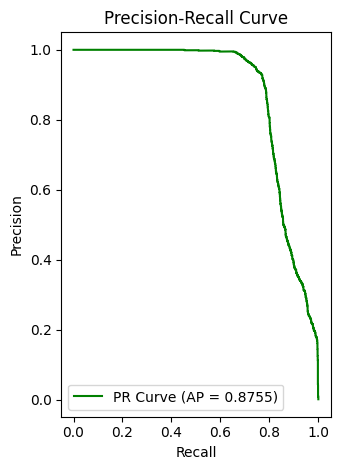

In [ ]:
#PR curve
precision_vals, recall_vals, _ = precision_recall_curve(y_test, final_preds_prob)
avg_precision = average_precision_score(y_test, final_preds_prob)

plt.subplot(1, 2, 2)
plt.plot(recall_vals, precision_vals, color='green', label=f'PR Curve (AP = {avg_precision:.4f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()

plt.tight_layout()
plt.show()

# **Results**

In [ ]:
def create_results_table(models, metrics):
    data = []
    for model in models:
        row = {'Model': model}
        for metric in metrics:
            var_name = f"{model}_{metric}"
            # Get the value from the global namespace if it exists
            if var_name in globals():
                value = globals()[var_name]
                # Check if the value is a NumPy array or list
                if isinstance(value, (np.ndarray, list)):
                    # If it is, take the mean for representation
                    row[metric] = np.mean(value)
                else:
                    row[metric] = value
            else:
                row[metric] = np.nan
        data.append(row)
    df = pd.DataFrame(data)
    plot_df = df.copy()
    for metric in metrics:
        # Apply formatting after ensuring it's a single number
        df[metric] = df[metric].map(lambda x: f"{x:.2%}" if not pd.isna(x) else np.nan)
    print("Model Evaluation Results:")
    display(df)

    return df, plot_df

In [ ]:
def create_comparison_plots(plot_df, models, metrics):
    # Prepare data for plotting
    plot_data = plot_df.drop('Model', axis=1).set_index(plot_df['Model'])

    # Set up the plot
    fig = plt.figure(figsize=(15, 10))
    gs = gridspec.GridSpec(2, 2, figure=fig)

    # 1. Bar chart comparing all models across all metrics
    ax1 = fig.add_subplot(gs[0, :])
    plot_data.plot(kind='bar', ax=ax1)
    ax1.set_title('Model Performance Comparison', fontsize=14)
    ax1.set_ylabel('Score')
    ax1.grid(axis='y', linestyle='--', alpha=0.7)
    ax1.legend(title='Metrics')

    # 2. Heatmap
    ax2 = fig.add_subplot(gs[1, 0])
    sns.heatmap(plot_data, annot=True, cmap='YlGnBu', fmt='.3f', ax=ax2)
    ax2.set_title('Performance Heatmap', fontsize=14)

    # 3. Radar chart
    ax3 = fig.add_subplot(gs[1, 1], polar=True)

    # Prepare data for radar chart
    values = plot_data.values.tolist()
    angles = np.linspace(0, 2*np.pi, len(metrics), endpoint=False).tolist()

    # Close the loop
    for i in range(len(values)):
        values[i] += values[i][:1]
    angles += angles[:1]

    # Plot each model
    for i, model in enumerate(models):
        ax3.plot(angles, values[i], linewidth=2, label=model)
        ax3.fill(angles, values[i], alpha=0.1)

    # Set labels
    ax3.set_xticks(angles[:-1])
    ax3.set_xticklabels(metrics)
    ax3.set_title('Radar Chart of Model Performance', fontsize=14)
    ax3.legend(loc='upper right', bbox_to_anchor=(0.1, 0.1))

    plt.tight_layout()
    plt.savefig('model_comparison_plots.png', dpi=300, bbox_inches='tight')
    plt.show()

In [ ]:
models = ['GBT', 'RF', 'LOGR', 'BOOST', 'META']
metrics = ['f1', 'precision', 'recall', 'accuracy', 'fpr', 'roc_auc']

In [ ]:
results_df, plot_df = create_results_table(models, metrics)
results_df.to_csv('model_evaluation_results.csv', index=False)

Model Evaluation Results:


,Model,f1,precision,recall,accuracy,fpr,roc_auc
0,GBT,75.29%,82.20%,69.45%,99.94%,0.02%,99.90%
1,RF,82.51%,93.59%,73.77%,99.96%,0.01%,99.88%
2,LOGR,29.09%,0.77%,98.29%,99.87%,52.90%,98.36%
3,BOOST,49.47%,33.39%,95.44%,99.75%,0.25%,99.94%
4,META,84.21%,92.75%,77.12%,99.96%,0.01%,99.94%


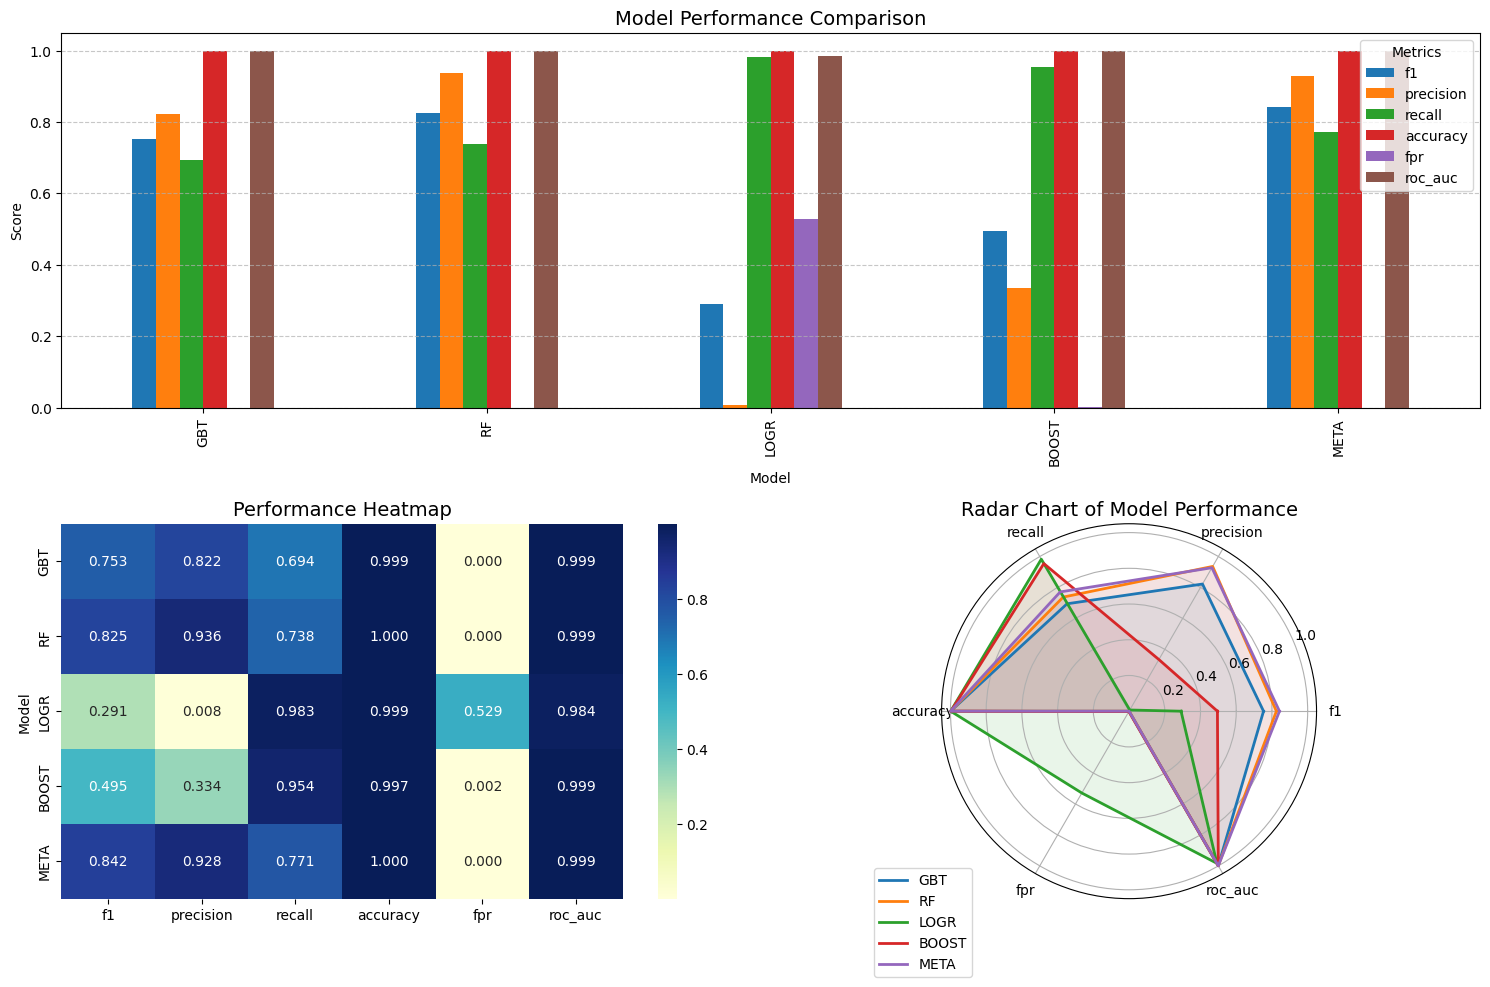

In [ ]:
create_comparison_plots(plot_df, models, metrics)

Visualizing XGBoost model: GBT


/usr/local/lib/python3.11/dist-packages/xgboost/plotting.py:267: FutureWarning: The `num_trees` parameter is deprecated, use `tree_idx` insetad. 
  warnings.warn(


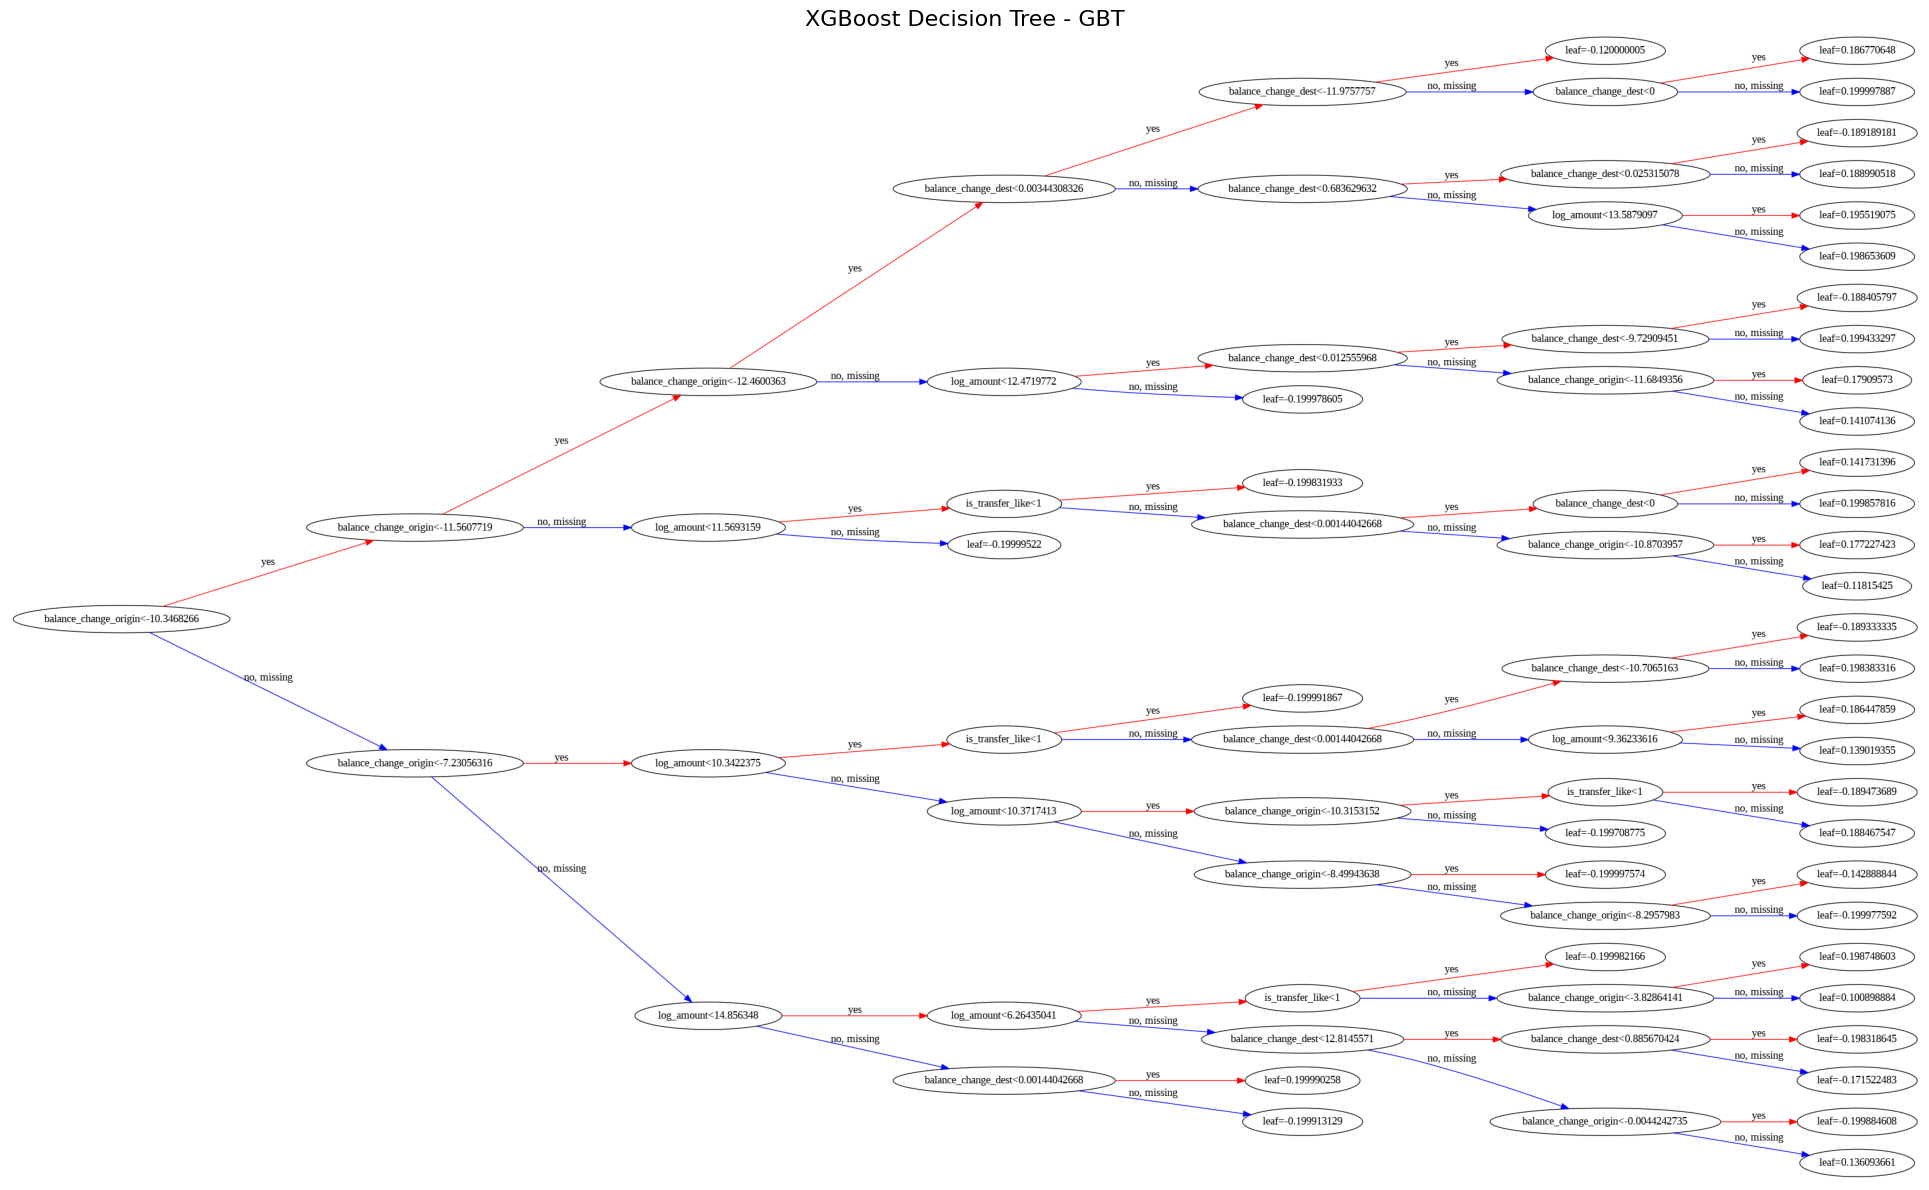

Visualizing Random Forest model: RF


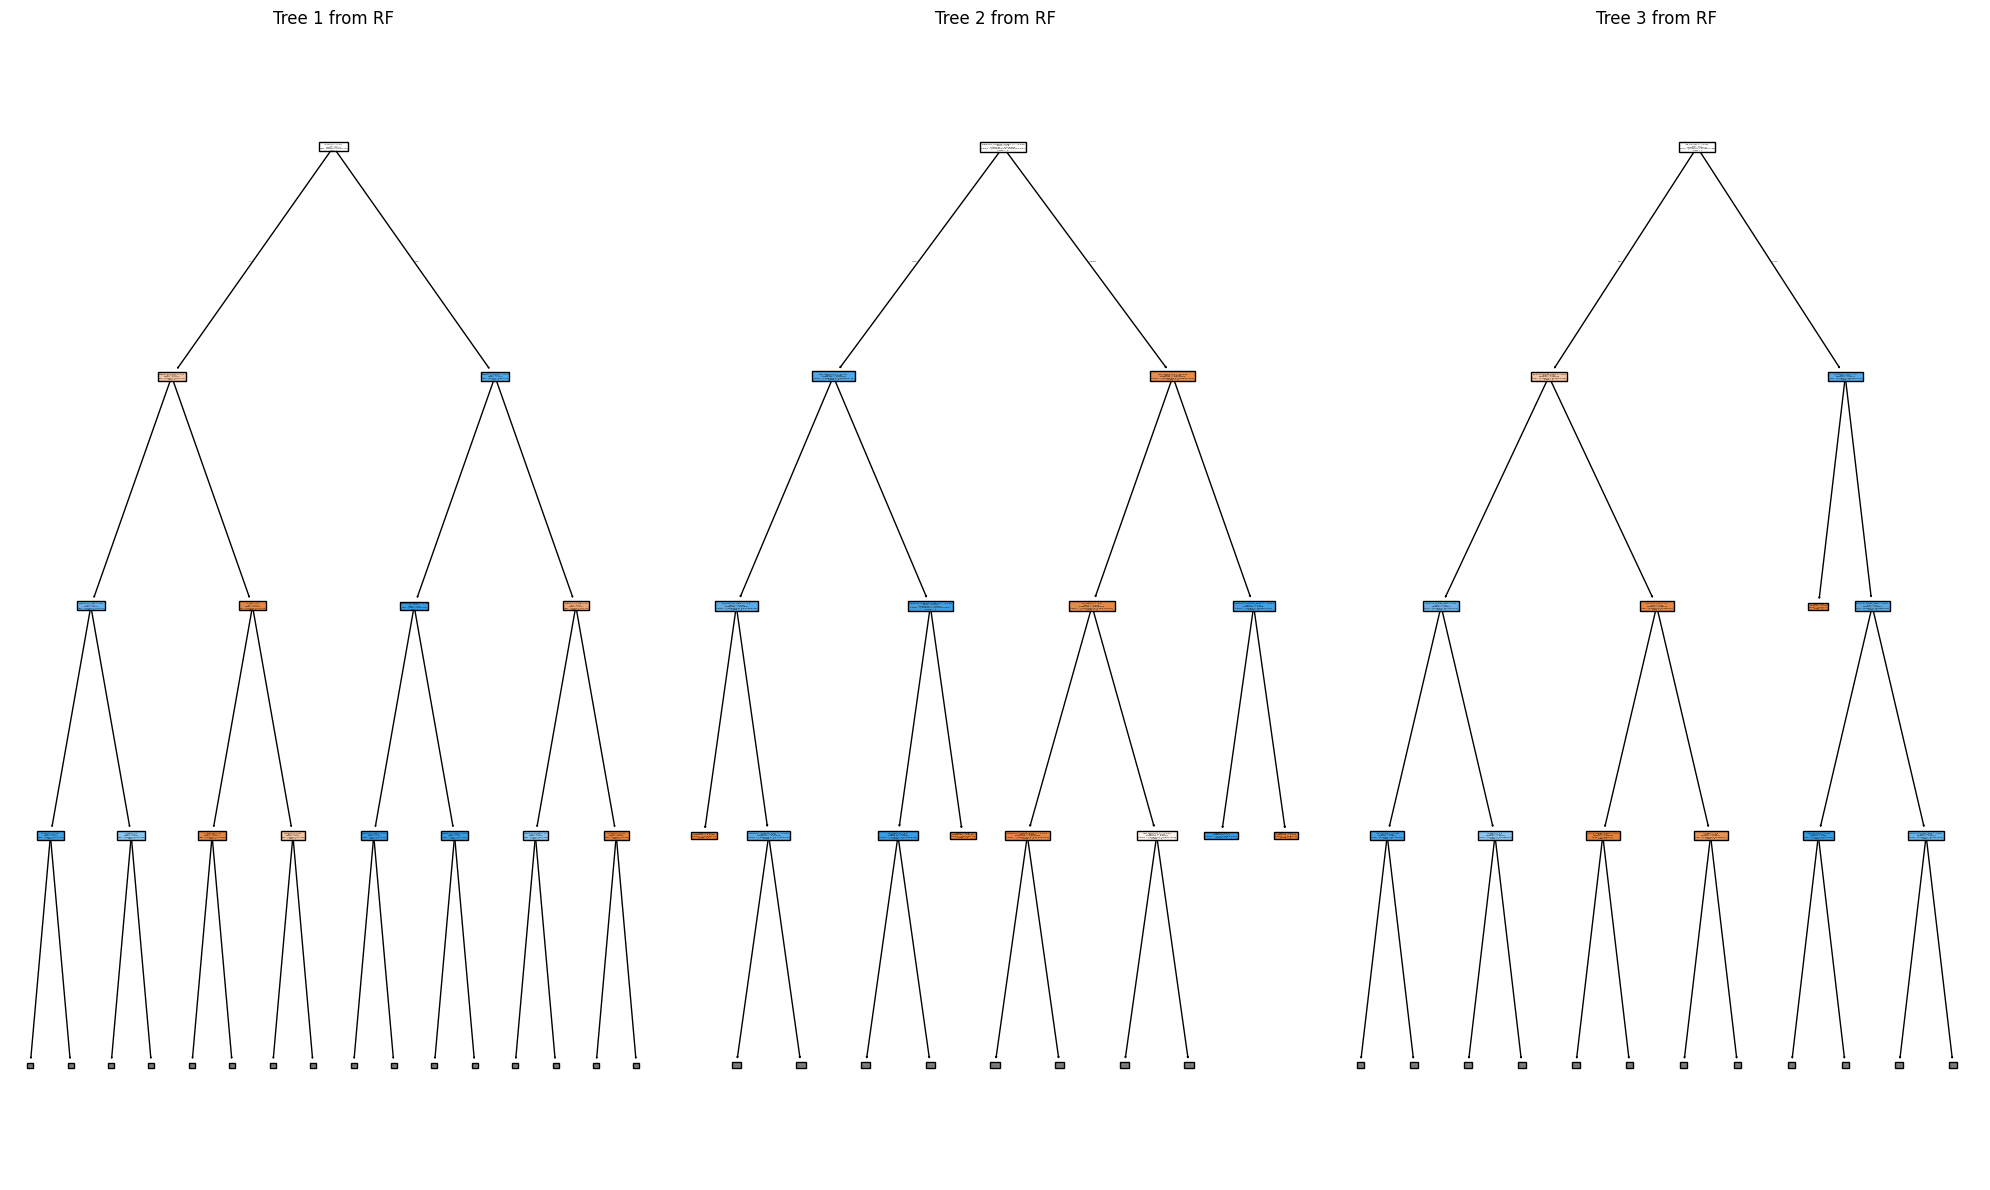

In [ ]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

feature_names = features = ['log_amount', 'balance_change_origin', 'balance_change_dest',
            'is_night', 'is_transfer_like']

def visualize_trees(model, model_name=None, feature_names=None, class_names=None, max_depth=3, figsize=(20, 12)):
    if model_name is None:
        model_name = type(model).__name__

    #GBT
    if str(type(model)).find('xgboost') != -1:
        try:
            import xgboost as xgb
            print(f"Visualizing XGBoost model: {model_name}")
            plt.figure(figsize=figsize)

            xgb.plot_tree(model, num_trees=0,
                             rankdir='LR', ax=plt.gca())

            plt.title(f"XGBoost Decision Tree - {model_name}", fontsize=16)
            plt.tight_layout()
            plt.savefig(f'{model_name}_tree.png', dpi=300, bbox_inches='tight')
            plt.show()

        except ImportError:
            print("XGBoost not installed. Install with: pip install xgboost")
            return
        except Exception as e:
            print(f"Error visualizing XGBoost tree: {e}")
            return

    #RF
    elif hasattr(model, 'estimators_') and str(type(model)).find('RandomForest') != -1:
        print(f"Visualizing Random Forest model: {model_name}")
        n_trees = min(3, len(model.estimators_))
        fig, axes = plt.subplots(1, n_trees, figsize=figsize)

        if n_trees == 1:
            axes = [axes]

        for i, ax in enumerate(axes):
            plot_tree(model.estimators_[i],
                      feature_names=feature_names,
                      class_names=class_names,
                      filled=True,
                      max_depth=max_depth,
                      ax=ax)
            ax.set_title(f"Tree {i+1} from {model_name}", fontsize=12)

        plt.tight_layout()
        plt.savefig(f'{model_name}_trees.png', dpi=300, bbox_inches='tight')
        plt.show()
    else:
        print(f"Model type not supported for visualization: {type(model)}")
        print("Supported types: XGBoost, RandomForestClassifier, AdaBoostClassifier")

visualize_trees(GBT_model, model_name="GBT", feature_names=feature_names, class_names=["0", "1"])
visualize_trees(RF_model, model_name="RF", feature_names=feature_names, class_names=["0", "1"])

In [ ]:
def create_comparison_plots(models, metrics_dict):
    """
    Creates comparison plots for different models and metrics.

    Args:
        models (list): A list of model names.
        metrics_dict (dict): A dictionary where keys are model names and
                             values are dictionaries of metrics.
                             e.g., {'GBT': {'F1': 0.85, 'Precision': 0.9, ...}, ...}
    """
    # Prepare data for plotting
    plot_df = pd.DataFrame(metrics_dict).T.reset_index()
    plot_df.rename(columns={'index': 'Model'}, inplace=True)
    plot_data = plot_df.drop('Model', axis=1).set_index(plot_df['Model'])
    # Set up the plot
    fig = plt.figure(figsize=(15, 10))
    gs = gridspec.GridSpec(2, 2, figure=fig)

    # 1. Bar chart comparing all models across all metrics
    ax1 = fig.add_subplot(gs[0, :])
    plot_data.plot(kind='bar', ax=ax1)
    ax1.set_title('Model Performance Comparison', fontsize=14)
    ax1.set_ylabel('Score')
    ax1.grid(axis='y', linestyle='--', alpha=0.7)
    ax1.legend(title='Metrics')

    # 2. Heatmap
    ax2 = fig.add_subplot(gs[1, 0])
    sns.heatmap(plot_data, annot=True, cmap='YlGnBu', fmt='.5f', ax=ax2)
    ax2.set_title('Performance Heatmap', fontsize=14)

    # 3. Radar chart
    ax3 = fig.add_subplot(gs[1, 1], polar=True)

    # Prepare data for radar chart
    values = plot_data.values.tolist()
    angles = np.linspace(0, 2*np.pi, len(metrics), endpoint=False).tolist()

    # Close the loop
    for i in range(len(values)):
        values[i] += values[i][:1]
    angles += angles[:1]

    # Plot each model
    for i, model in enumerate(models):
        ax3.plot(angles, values[i], linewidth=2, label=model)
        ax3.fill(angles, values[i], alpha=0.1)

    # Set labels
    ax3.set_xticks(angles[:-1])
    ax3.set_xticklabels(metrics)
    ax3.set_title('Radar Chart of Model Performance', fontsize=14)
    ax3.legend(loc='upper right', bbox_to_anchor=(0.1, 0.1))

    plt.tight_layout()
    plt.savefig('model_comparison_plots.png', dpi=300, bbox_inches='tight')
    plt.show()

In [ ]:
models = ['GBT', 'RF', 'BOOST', 'LOGR', 'META']
metrics = ['F1', 'Precision', 'Recall', 'Accuracy', 'FPR', 'ROC AUC']
metrics_dict = {
    'GBT': {'F1': 0.7529, 'Precision': 0.8220, 'Recall': 0.6945,
            'Accuracy': 0.9994, 'FPR': 0.02, 'ROC AUC': 0.9990},
    'RF': {'F1': 0.8251, 'Precision': 0.9359,  'Recall': 0.7377,
            'Accuracy': 0.9996, 'FPR': 0.01, 'ROC AUC': 0.9988},
    'BOOST': {'F1': 0.4947, 'Precision': 0.3339,  'Recall': 0.9544,
            'Accuracy': 0.9975, 'FPR': 0.25, 'ROC AUC': 0.9994},
    'LOGR': {'F1': 0.2909, 'Precision': 0.77,  'Recall': 0.9829,
            'Accuracy': 0.9987, 'FPR': 0.5290, 'ROC AUC': 0.9836},
    'META': {'F1': 0.8421, 'Precision': 0.9275,  'Recall': 0.7712,
            'Accuracy': 0.9996, 'FPR': 0.01, 'ROC AUC': 0.9994},
}

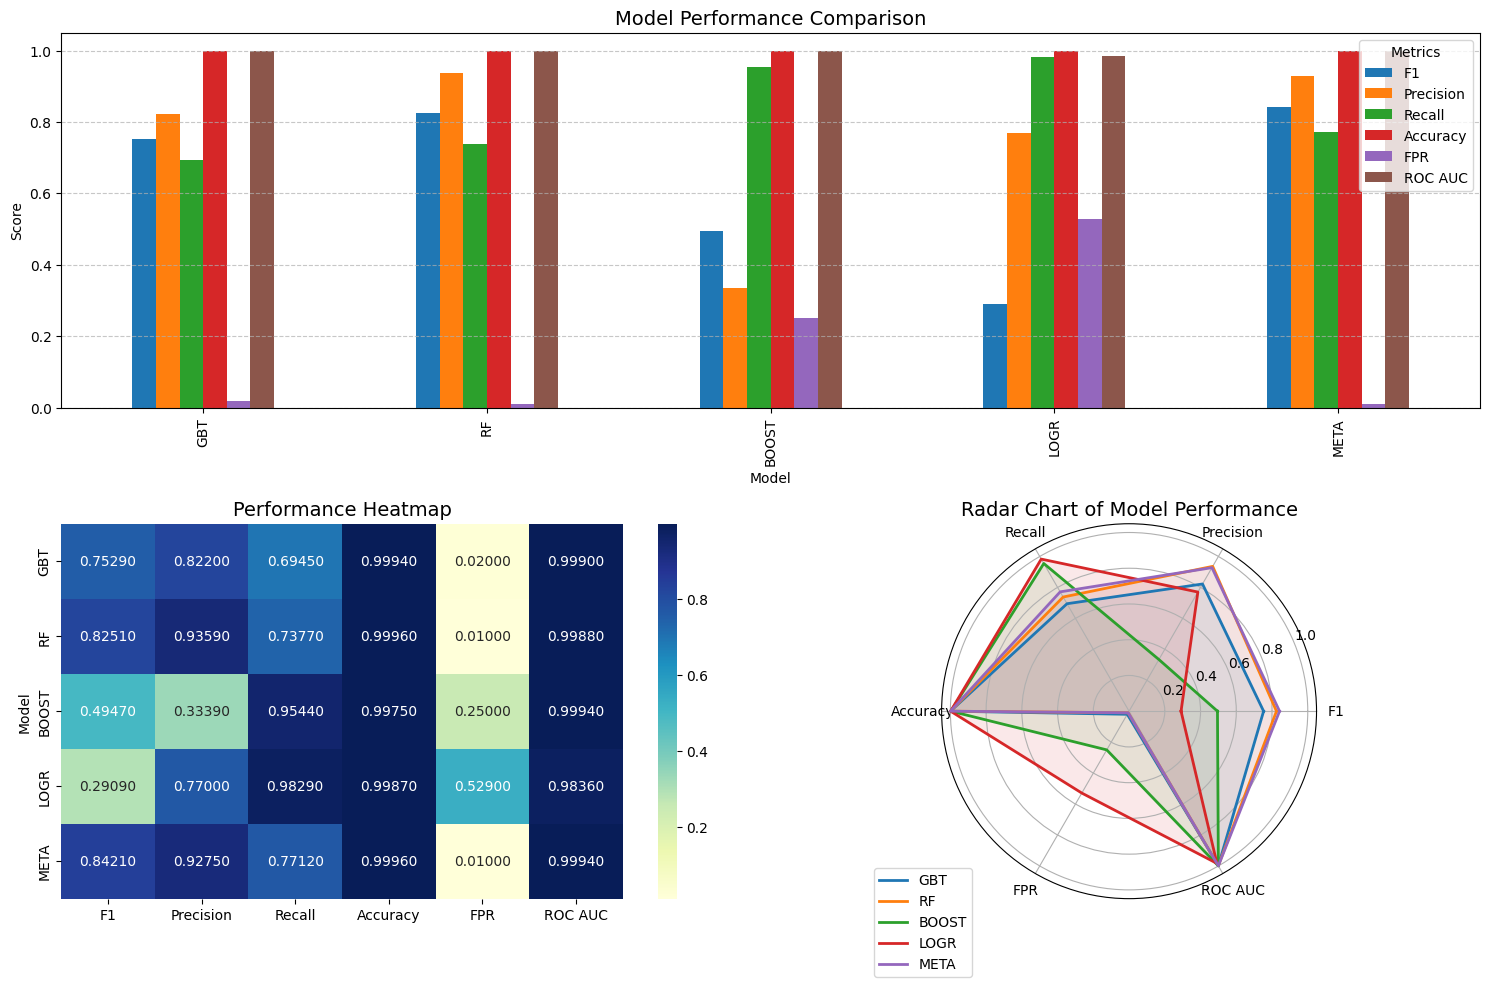

In [ ]:
create_comparison_plots(models, metrics_dict)